# 02 - Transfer Learning con ResNet18 para Clasificación de Tumores Cerebrales

## 1. Objetivo del notebook

El objetivo de este notebook es entrenar un modelo de clasificación de imágenes usando **transfer learning** con PyTorch y torchvision, tomando como base una arquitectura preentrenada liviana: **ResNet18**.

El modelo se adaptará para clasificar imágenes de resonancia magnética cerebral en cuatro clases:

- `glioma`
- `meningioma`
- `notumor`
- `pituitary`

Este notebook mantiene una estructura equivalente al notebook de CNN baseline para facilitar la comparación final entre ambos enfoques.

## Contexto del problema

En el notebook baseline se entrenó una CNN desde cero sobre el dataset local, usando `Training/` para entrenamiento y validación, y reservando `Testing/` exclusivamente para evaluación final.

En este notebook se utilizará transfer learning con pesos preentrenados en ImageNet. La idea principal es aprovechar características visuales ya aprendidas por ResNet18 y adaptar su capa final al problema médico de cuatro clases.

Aunque ImageNet no es un dataset médico, transfer learning suele ser útil cuando se trabaja con imágenes y se desea mejorar el desempeño o reducir el tiempo de entrenamiento frente a una CNN entrenada desde cero.

## Configuración inicial

En este primer paso se cargan las librerías necesarias, se fijan semillas para reproducibilidad, se definen rutas del proyecto y se preparan los parámetros globales del experimento.

In [1]:
# Paso 1 - Configuracion inicial del entorno para transfer learning

from pathlib import Path
import os
import random
import json
import time
import copy
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms, models
from torchvision.models import ResNet18_Weights

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

warnings.filterwarnings("ignore")

# Reproducibilidad
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Rutas del proyecto
PROJECT_ROOT = Path.cwd()
TRAIN_DIR = PROJECT_ROOT / "Training"
TEST_DIR = PROJECT_ROOT / "Testing"

MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"

MODELS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

# Parametros globales del experimento
CLASS_NAMES = ["glioma", "meningioma", "notumor", "pituitary"]
NUM_CLASSES = len(CLASS_NAMES)

IMAGE_SIZE = 224
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.20
NUM_WORKERS = 0

# Parametros especificos de transfer learning
MODEL_NAME = "resnet18"
TRANSFER_MODEL_PATH = MODELS_DIR / "transfer_resnet18.pth"
TRANSFER_METRICS_PATH = METRICS_DIR / "transfer_resnet18_metrics.json"
TRANSFER_CURVES_PATH = FIGURES_DIR / "transfer_resnet18_training_curves.png"
TRANSFER_CONFUSION_MATRIX_PATH = FIGURES_DIR / "transfer_resnet18_confusion_matrix.png"

BASELINE_METRICS_PATH = METRICS_DIR / "cnn_baseline_metrics.json"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Dispositivo seleccionado: {DEVICE}")
print(f"Ruta del proyecto: {PROJECT_ROOT}")
print(f"Training existe: {TRAIN_DIR.exists()} - {TRAIN_DIR}")
print(f"Testing existe: {TEST_DIR.exists()} - {TEST_DIR}")
print(f"Clases esperadas: {CLASS_NAMES}")
print(f"Modelo seleccionado para transfer learning: {MODEL_NAME}")

PyTorch version: 2.12.1+cpu
Dispositivo seleccionado: cpu
Ruta del proyecto: c:\Users\admin\Desktop\Maestria en BI y Analisis de Datos\M3\06 - Redes Neuronales y Deep Learning\Proyecto Final
Training existe: True - c:\Users\admin\Desktop\Maestria en BI y Analisis de Datos\M3\06 - Redes Neuronales y Deep Learning\Proyecto Final\Training
Testing existe: True - c:\Users\admin\Desktop\Maestria en BI y Analisis de Datos\M3\06 - Redes Neuronales y Deep Learning\Proyecto Final\Testing
Clases esperadas: ['glioma', 'meningioma', 'notumor', 'pituitary']
Modelo seleccionado para transfer learning: resnet18


## 2. Validación de estructura del dataset

Antes de entrenar el modelo con transfer learning, se valida que las carpetas del dataset estén organizadas correctamente y que cada clase tenga imágenes disponibles.

El dataset está dividido en:

- `Training/`: se utilizará para entrenamiento y validación.
- `Testing/`: se reservará exclusivamente para la evaluación final.

En esta etapa revisaremos:

1. Qué clases existen en cada split.
2. Cuántas imágenes hay por clase.
3. Si la distribución está balanceada.
4. Si las clases detectadas coinciden con las clases esperadas del proyecto.

Esta validación es especialmente importante porque el modelo ResNet18 recibirá imágenes desde estas carpetas usando `torchvision.datasets.ImageFolder`, que asigna etiquetas automáticamente según los nombres de las carpetas.

In [2]:
# Paso 2 - Validacion de estructura y conteo de imagenes

def count_images_by_class(directory: Path) -> pd.DataFrame:
    rows = []
    valid_extensions = {".jpg", ".jpeg", ".png"}

    for class_dir in sorted(directory.iterdir()):
        if class_dir.is_dir():
            image_files = [
                file
                for file in class_dir.iterdir()
                if file.suffix.lower() in valid_extensions
            ]

            rows.append({
                "split": directory.name,
                "class_name": class_dir.name,
                "image_count": len(image_files),
            })

    return pd.DataFrame(rows)


train_counts = count_images_by_class(TRAIN_DIR)
test_counts = count_images_by_class(TEST_DIR)

dataset_counts = pd.concat([train_counts, test_counts], ignore_index=True)

display(dataset_counts)

pivot_counts = dataset_counts.pivot(
    index="class_name",
    columns="split",
    values="image_count"
).fillna(0).astype(int)

pivot_counts["total"] = pivot_counts.sum(axis=1)

display(pivot_counts)

detected_train_classes = sorted(train_counts["class_name"].tolist())
detected_test_classes = sorted(test_counts["class_name"].tolist())
expected_classes = sorted(CLASS_NAMES)

print("Clases esperadas:", expected_classes)
print("Clases detectadas en Training:", detected_train_classes)
print("Clases detectadas en Testing:", detected_test_classes)

print("\nTotal imagenes Training:", int(train_counts["image_count"].sum()))
print("Total imagenes Testing:", int(test_counts["image_count"].sum()))
print("Total general:", int(dataset_counts["image_count"].sum()))

if detected_train_classes == expected_classes and detected_test_classes == expected_classes:
    print("\nValidacion de clases: OK")
else:
    print("\nValidacion de clases: revisar diferencias entre clases esperadas y detectadas.")

,split,class_name,image_count
0,Training,glioma,1400
1,Training,meningioma,1400
2,Training,notumor,1400
3,Training,pituitary,1400
4,Testing,glioma,400
5,Testing,meningioma,400
6,Testing,notumor,400
7,Testing,pituitary,400


split,Testing,Training,total
class_name,,,
glioma,400,1400,1800
meningioma,400,1400,1800
notumor,400,1400,1800
pituitary,400,1400,1800


Clases esperadas: ['glioma', 'meningioma', 'notumor', 'pituitary']
Clases detectadas en Training: ['glioma', 'meningioma', 'notumor', 'pituitary']
Clases detectadas en Testing: ['glioma', 'meningioma', 'notumor', 'pituitary']

Total imagenes Training: 5600
Total imagenes Testing: 1600
Total general: 7200

Validacion de clases: OK


### Interpretación de la estructura del dataset

La validación confirma que el dataset está organizado correctamente. Las cuatro clases esperadas aparecen tanto en `Training/` como en `Testing/`:

- `glioma`
- `meningioma`
- `notumor`
- `pituitary`

El conjunto de entrenamiento contiene 5,600 imágenes y el conjunto de prueba contiene 1,600 imágenes, para un total de 7,200 imágenes.

Además, la validación de clases fue exitosa, por lo que no se detectaron diferencias entre las clases esperadas y las carpetas disponibles en el proyecto.

## 3. Distribución de imágenes por clase

En este paso se visualiza la cantidad de imágenes por clase en los conjuntos `Training/` y `Testing/`.

Esta revisión permite confirmar visualmente si el dataset está balanceado. Un dataset balanceado facilita el entrenamiento y permite interpretar métricas como accuracy, precision macro, recall macro y F1 macro de forma más confiable.

Para transfer learning, esta revisión también ayuda a decidir si será necesario aplicar estrategias adicionales como ponderación de clases o muestreo balanceado. Si las clases están equilibradas, se puede continuar con una configuración estándar de entrenamiento.

,split,class_name,image_count,percentage_within_split
0,Training,glioma,1400,25.0
1,Training,meningioma,1400,25.0
2,Training,notumor,1400,25.0
3,Training,pituitary,1400,25.0
4,Testing,glioma,400,25.0
5,Testing,meningioma,400,25.0
6,Testing,notumor,400,25.0
7,Testing,pituitary,400,25.0


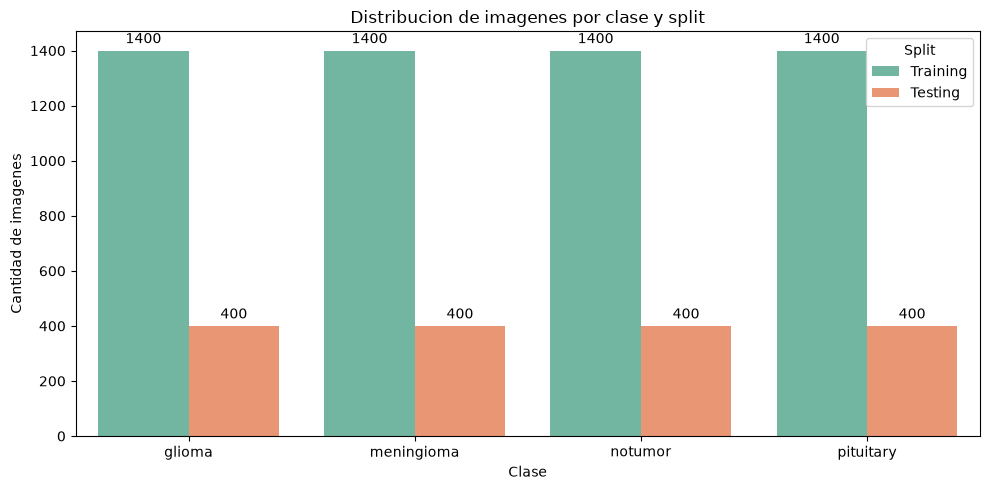

Resumen de balance por split:
Training: minimo=1400, maximo=1400, diferencia=0
Testing: minimo=400, maximo=400, diferencia=0


In [3]:
# Paso 3 - Visualizacion de distribucion por clase

distribution_summary = dataset_counts.copy()
distribution_summary["percentage_within_split"] = distribution_summary.groupby("split")["image_count"].transform(
    lambda values: values / values.sum() * 100
)

display(distribution_summary)

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=distribution_summary,
    x="class_name",
    y="image_count",
    hue="split",
    order=CLASS_NAMES,
    palette="Set2"
)

plt.title("Distribucion de imagenes por clase y split")
plt.xlabel("Clase")
plt.ylabel("Cantidad de imagenes")
plt.legend(title="Split")

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.tight_layout()
plt.show()

print("Resumen de balance por split:")
for split_name in ["Training", "Testing"]:
    split_data = distribution_summary[distribution_summary["split"] == split_name]
    min_count = int(split_data["image_count"].min())
    max_count = int(split_data["image_count"].max())
    difference = max_count - min_count

    print(f"{split_name}: minimo={min_count}, maximo={max_count}, diferencia={difference}")

### Interpretación de la distribución por clase

La distribución de imágenes confirma que el dataset está perfectamente balanceado.

En el conjunto `Training`, cada clase contiene 1,400 imágenes. En el conjunto `Testing`, cada clase contiene 400 imágenes. La diferencia entre la clase con menos imágenes y la clase con más imágenes es 0 en ambos splits.

Esto es favorable para el entrenamiento, ya que reduce el riesgo de que el modelo aprenda a favorecer una clase únicamente por tener mayor cantidad de ejemplos.

También permite utilizar métricas globales como accuracy, aunque para una evaluación más completa se reportarán métricas por clase y métricas macro como precision, recall y F1-score.

## 4. Revisión visual de ejemplos por clase

En datasets de imágenes, una parte importante del análisis exploratorio consiste en revisar ejemplos visuales de cada clase. Esto permite observar diferencias generales entre categorías, variaciones de orientación, contraste, tamaño y formato de las imágenes.

A continuación se muestran ejemplos del conjunto de entrenamiento para cada una de las cuatro clases.

Esta revisión es útil para transfer learning porque ResNet18 espera entradas visuales consistentes. Por eso, antes del entrenamiento será necesario aplicar transformaciones que unifiquen tamaño, canales y normalización.

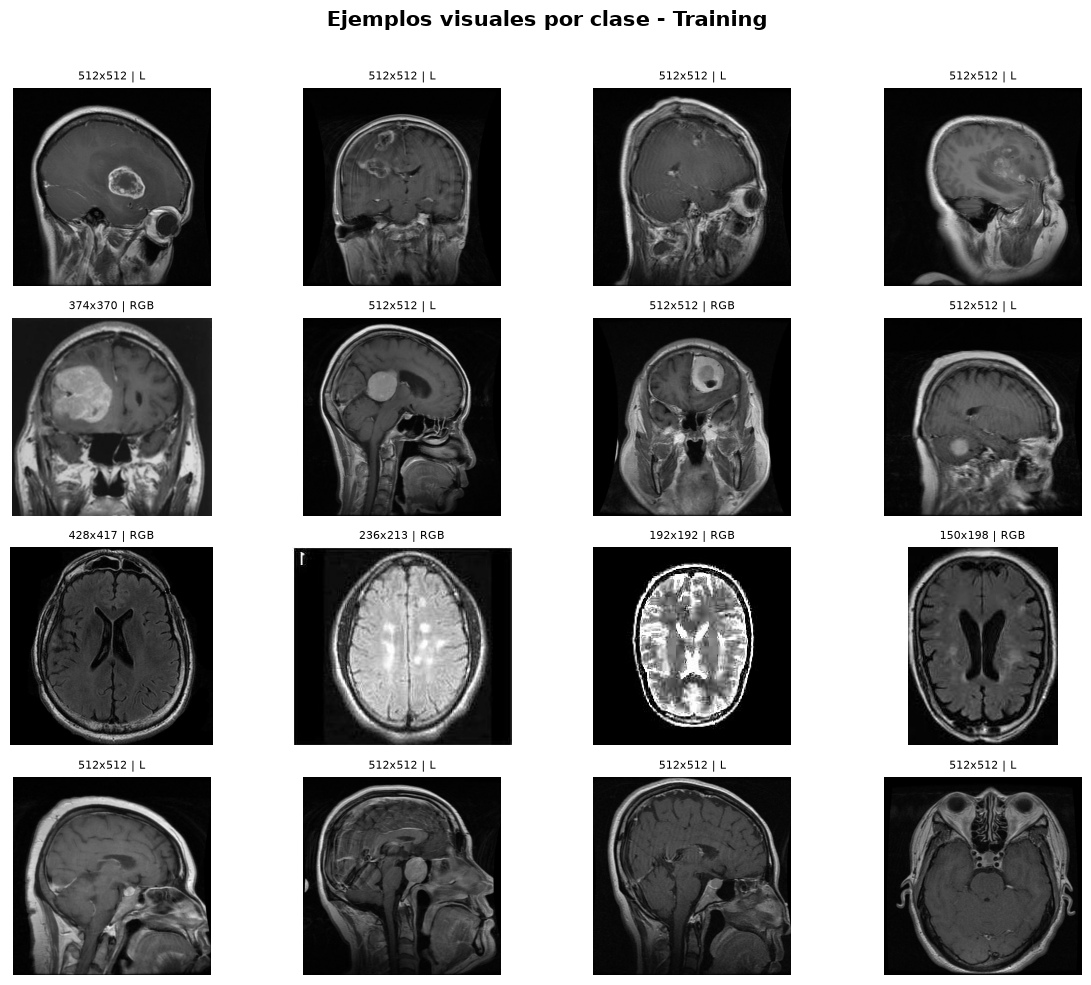

Figura guardada en: c:\Users\admin\Desktop\Maestria en BI y Analisis de Datos\M3\06 - Redes Neuronales y Deep Learning\Proyecto Final\outputs\figures\transfer_resnet18_sample_images_by_class.png


In [4]:
# Paso 4 - Visualizacion de ejemplos por clase

def get_image_files(class_dir: Path):
    valid_extensions = {".jpg", ".jpeg", ".png"}
    return sorted([
        file
        for file in class_dir.iterdir()
        if file.suffix.lower() in valid_extensions
    ])


samples_per_class = 4

fig, axes = plt.subplots(
    nrows=NUM_CLASSES,
    ncols=samples_per_class,
    figsize=(12, 10)
)

for row_idx, class_name in enumerate(CLASS_NAMES):
    class_dir = TRAIN_DIR / class_name
    image_files = get_image_files(class_dir)

    selected_files = random.sample(image_files, samples_per_class)

    for col_idx, image_path in enumerate(selected_files):
        image = Image.open(image_path)

        axes[row_idx, col_idx].imshow(image, cmap="gray")
        axes[row_idx, col_idx].axis("off")

        if col_idx == 0:
            axes[row_idx, col_idx].set_ylabel(
                class_name,
                fontsize=11,
                fontweight="bold",
                rotation=0,
                labelpad=45,
                va="center"
            )

        axes[row_idx, col_idx].set_title(
            f"{image.size[0]}x{image.size[1]} | {image.mode}",
            fontsize=8
        )

plt.suptitle(
    "Ejemplos visuales por clase - Training",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.97])

sample_grid_path = FIGURES_DIR / "transfer_resnet18_sample_images_by_class.png"
plt.savefig(sample_grid_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {sample_grid_path}")

### Interpretación de la revisión visual

La revisión visual confirma que las imágenes corresponden a estudios de resonancia magnética cerebral con distintas orientaciones, cortes anatómicos y niveles de contraste. También se observa variabilidad en la apariencia de las lesiones y en la presentación de cada clase.

Desde el punto de vista técnico, los títulos de las imágenes muestran que no todas tienen las mismas dimensiones y que existen imágenes tanto en escala de grises (`L`) como en formato `RGB`.

Esta variabilidad justifica la necesidad de aplicar un preprocesamiento uniforme antes del entrenamiento con ResNet18. En particular, será necesario redimensionar todas las imágenes a `224x224`, convertirlas a tres canales y aplicar la normalización correspondiente a ImageNet.

## 5. Análisis técnico de dimensiones y canales

Además de revisar ejemplos visuales, es necesario inspeccionar las propiedades técnicas de las imágenes. Para entrenar un modelo de transfer learning con ResNet18, todas las entradas deben tener una forma consistente.

En esta sección se revisan:

- Ancho y alto de las imágenes.
- Modo de color (`RGB`, escala de grises `L`, etc.).
- Distribución de tamaños por conjunto y clase.
- Cantidad de tamaños únicos.
- Modos de color detectados.

Este análisis permite justificar el redimensionamiento a `224x224`, la conversión a tres canales y el uso de normalización ImageNet antes del entrenamiento.

In [5]:
# Paso 5 - Analisis tecnico de dimensiones y canales

def inspect_image_properties(directory: Path) -> pd.DataFrame:
    rows = []
    valid_extensions = {".jpg", ".jpeg", ".png"}

    for class_dir in sorted(directory.iterdir()):
        if not class_dir.is_dir():
            continue

        image_files = [
            file
            for file in class_dir.iterdir()
            if file.suffix.lower() in valid_extensions
        ]

        for image_path in image_files:
            with Image.open(image_path) as image:
                width, height = image.size
                mode = image.mode

            rows.append({
                "split": directory.name,
                "class_name": class_dir.name,
                "file_name": image_path.name,
                "width": width,
                "height": height,
                "mode": mode,
                "aspect_ratio": round(width / height, 3),
            })

    return pd.DataFrame(rows)


train_properties = inspect_image_properties(TRAIN_DIR)
test_properties = inspect_image_properties(TEST_DIR)

image_properties = pd.concat(
    [train_properties, test_properties],
    ignore_index=True
)

display(image_properties.head())

dimension_summary = image_properties.groupby(["split", "class_name"]).agg(
    image_count=("file_name", "count"),
    min_width=("width", "min"),
    max_width=("width", "max"),
    min_height=("height", "min"),
    max_height=("height", "max"),
    unique_sizes=("file_name", lambda x: image_properties.loc[x.index, ["width", "height"]].drop_duplicates().shape[0]),
    unique_modes=("mode", lambda x: ", ".join(sorted(x.unique()))),
).reset_index()

display(dimension_summary)

mode_counts = image_properties.groupby(
    ["split", "class_name", "mode"]
).size().reset_index(name="count")

display(mode_counts)

print("Total de tamanos unicos:", image_properties[["width", "height"]].drop_duplicates().shape[0])
print("Modos de color detectados:", sorted(image_properties["mode"].unique()))

,split,class_name,file_name,width,height,mode,aspect_ratio
0,Training,glioma,Tr-gl_1.jpg,512,512,L,1.0
1,Training,glioma,Tr-gl_10.jpg,512,512,L,1.0
2,Training,glioma,Tr-gl_100.jpg,512,512,L,1.0
3,Training,glioma,Tr-gl_1000.jpg,512,512,L,1.0
4,Training,glioma,Tr-gl_1001.jpg,512,512,L,1.0


,split,class_name,image_count,min_width,max_width,min_height,max_height,unique_sizes,unique_modes
0,Testing,glioma,400,175,640,167,665,62,"L, RGB"
1,Testing,meningioma,400,174,1149,195,1019,99,"L, RGB"
2,Testing,notumor,400,150,680,168,680,55,"L, RGB"
3,Testing,pituitary,400,256,512,256,512,2,"L, RGB"
4,Training,glioma,1400,512,512,512,512,1,"L, RGB"
5,Training,meningioma,1400,180,1275,207,1427,116,"L, RGB"
6,Training,notumor,1400,150,1375,168,1446,250,"L, P, RGB, RGBA"
7,Training,pituitary,1400,201,1365,202,1365,27,"L, RGB"


,split,class_name,mode,count
0,Testing,glioma,L,226
1,Testing,glioma,RGB,174
2,Testing,meningioma,L,154
3,Testing,meningioma,RGB,246
4,Testing,notumor,L,6
5,Testing,notumor,RGB,394
6,Testing,pituitary,L,323
7,Testing,pituitary,RGB,77
8,Training,glioma,L,1173
9,Training,glioma,RGB,227


Total de tamanos unicos: 447
Modos de color detectados: ['L', 'P', 'RGB', 'RGBA']


### Interpretación del análisis técnico

El análisis técnico confirma que el dataset presenta variabilidad importante en las dimensiones y en los modos de color de las imágenes.

Aunque algunas imágenes tienen tamaño `512x512`, también se identifican imágenes más pequeñas y otras de mayor resolución. En total se detectaron 447 tamaños únicos, lo cual confirma que las imágenes no pueden enviarse directamente al modelo sin aplicar un redimensionamiento uniforme.

También se identificaron cuatro modos de color: `L`, `P`, `RGB` y `RGBA`.

El modo `L` corresponde a imágenes en escala de grises, `RGB` a imágenes de tres canales, `P` a imágenes con paleta de color y `RGBA` a imágenes con canal alfa. Como ResNet18 espera imágenes de tres canales, todas las imágenes deberán convertirse a `RGB` durante el preprocesamiento.

Con base en estos hallazgos, el pipeline de entrada aplicará:

- Conversión a `RGB`.
- Redimensionamiento uniforme a `224x224`.
- Transformación a tensor.
- Normalización con los parámetros de ImageNet.

Esto garantiza que todas las imágenes tengan una estructura compatible con ResNet18 antes del entrenamiento.

## 6. Visualización de dimensiones y modos de color

Después de confirmar que existen diferencias técnicas entre las imágenes, se generan visualizaciones para observar de forma más clara la dispersión de tamaños y la distribución de modos de color.

Estas gráficas ayudan a justificar el uso de un pipeline de preprocesamiento uniforme antes de entrenar el modelo con transfer learning.

En particular, permiten observar:

- La variación de ancho y alto entre imágenes.
- La concentración de imágenes alrededor de ciertos tamaños.
- La presencia de distintos modos de color.
- La necesidad de convertir todas las imágenes a `RGB`.

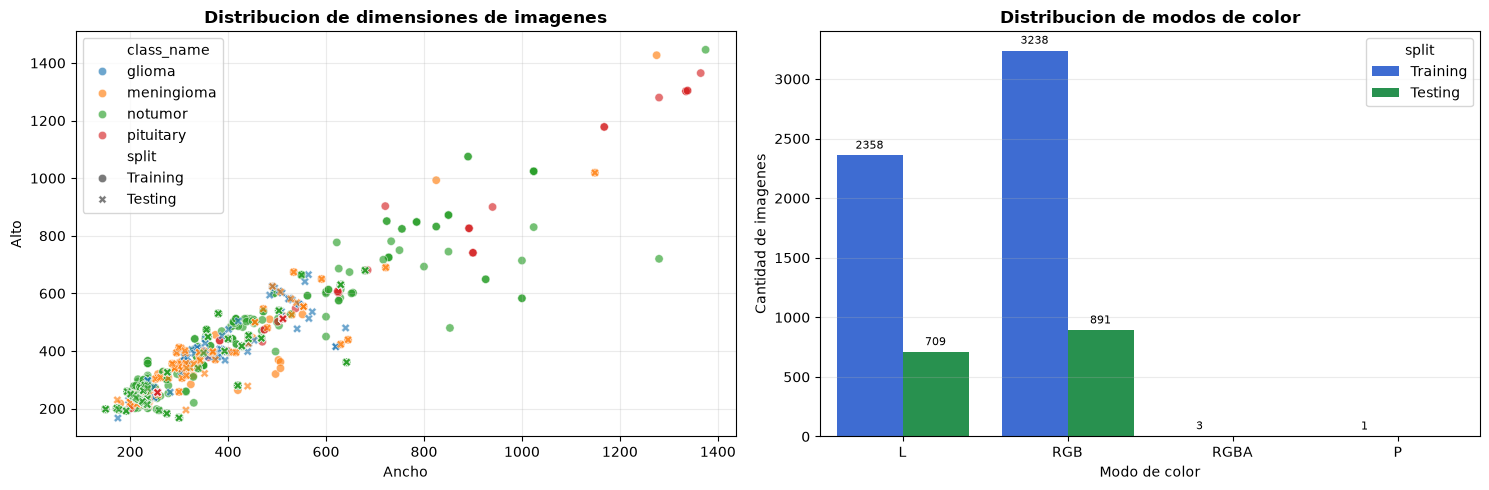

Figura guardada en: c:\Users\admin\Desktop\Maestria en BI y Analisis de Datos\M3\06 - Redes Neuronales y Deep Learning\Proyecto Final\outputs\figures\transfer_resnet18_image_dimensions_and_modes.png


In [6]:
# Paso 6 - Visualizacion de dimensiones y modos de color

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(
    data=image_properties,
    x="width",
    y="height",
    hue="class_name",
    style="split",
    alpha=0.65,
    ax=axes[0]
)

axes[0].set_title("Distribucion de dimensiones de imagenes", fontweight="bold")
axes[0].set_xlabel("Ancho")
axes[0].set_ylabel("Alto")
axes[0].grid(alpha=0.25)

sns.countplot(
    data=image_properties,
    x="mode",
    hue="split",
    palette=["#2563eb", "#16a34a"],
    ax=axes[1]
)

axes[1].set_title("Distribucion de modos de color", fontweight="bold")
axes[1].set_xlabel("Modo de color")
axes[1].set_ylabel("Cantidad de imagenes")
axes[1].grid(axis="y", alpha=0.25)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%d", padding=3, fontsize=8)

plt.tight_layout()

technical_eda_path = FIGURES_DIR / "transfer_resnet18_image_dimensions_and_modes.png"
plt.savefig(technical_eda_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {technical_eda_path}")

### Interpretación de dimensiones y modos de color

La visualización confirma una dispersión considerable en las dimensiones de las imágenes. Aunque existe una concentración importante alrededor de imágenes cuadradas de `512x512`, también aparecen imágenes más pequeñas y algunas imágenes de mayor resolución.

La gráfica de modos de color muestra que la mayoría de imágenes están en `RGB` o en escala de grises `L`. En `Training` se identifican 2,358 imágenes en modo `L`, 3,238 en modo `RGB`, 3 en modo `RGBA` y 1 en modo `P`. En `Testing` se identifican 709 imágenes en modo `L` y 891 en modo `RGB`.

Estas diferencias técnicas refuerzan la decisión de aplicar un pipeline de preprocesamiento uniforme antes del entrenamiento. Para ResNet18 se usará redimensionamiento a `224x224`, conversión a tres canales `RGB` y normalización con los valores de ImageNet.

## 7. Descripción breve de las clases

El dataset contiene cuatro categorías. Tres corresponden a tipos de tumores cerebrales y una corresponde a imágenes sin tumor aparente.

- `glioma`: grupo de tumores que se originan en células gliales del cerebro o la médula espinal. Estas células dan soporte y protección a las células nerviosas del sistema nervioso central. Fuente: [National Cancer Institute - Glioma](https://www.cancer.gov/publications/dictionaries/cancer-terms/def/glioma).

- `meningioma`: tumor que se forma en las meninges, que son capas delgadas de tejido que cubren y protegen el cerebro y la médula espinal. Generalmente se describe como un tumor de crecimiento lento. Fuente: [National Cancer Institute - Meningioma](https://www.cancer.gov/publications/dictionaries/cancer-terms/def/meningioma).

- `pituitary`: tumor localizado en la glándula pituitaria, estructura ubicada en la base del cerebro y relacionada con la producción de hormonas que afectan otras glándulas y funciones del cuerpo. Fuente: [National Cancer Institute - Pituitary Tumor](https://www.cancer.gov/publications/dictionaries/cancer-terms/def/pituitary-tumor).

- `notumor`: imágenes de resonancia magnética cerebral en las que no se identifica tumor dentro de la clasificación del dataset.

Esta descripción tiene fines académicos y no debe interpretarse como diagnóstico médico. El objetivo del proyecto es entrenar y evaluar modelos de clasificación de imágenes, no sustituir la evaluación de profesionales de salud.

## 8. Preprocesamiento y data augmentation

A partir del análisis exploratorio se definió un pipeline de preprocesamiento para estandarizar las imágenes antes de enviarlas a ResNet18.

El preprocesamiento aplicará:

1. Conversión a `RGB`, para asegurar tres canales de entrada.
2. Redimensionamiento a `224x224`.
3. Conversión a tensor.
4. Normalización con media y desviación estándar de ImageNet.

Para el conjunto de entrenamiento se agregará data augmentation moderado. Esto ayuda a mejorar la capacidad de generalización del modelo y reduce el riesgo de sobreajuste.

Las transformaciones aplicadas al entrenamiento serán moderadas porque se trabaja con imágenes médicas, donde transformaciones demasiado agresivas podrían alterar patrones anatómicos relevantes.

A diferencia del baseline, en este notebook se utilizará normalización ImageNet porque ResNet18 fue preentrenado con imágenes normalizadas usando esos valores.

In [7]:
# Paso 8 - Definicion de transformaciones para transfer learning

class ConvertToRGB:
    def __call__(self, image):
        return image.convert("RGB")


imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std = (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    ConvertToRGB(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

eval_transform = transforms.Compose([
    ConvertToRGB(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

print("Transformaciones de entrenamiento:")
print(train_transform)

print("\nTransformaciones de evaluacion:")
print(eval_transform)

print("\nNormalizacion utilizada:")
print(f"Media ImageNet: {imagenet_mean}")
print(f"Desviacion estandar ImageNet: {imagenet_std}")

Transformaciones de entrenamiento:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    RandomAffine(degrees=[0.0, 0.0], translate=(0.05, 0.05), scale=(0.95, 1.05))
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)

Transformaciones de evaluacion:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)

Normalizacion utilizada:
Media ImageNet: (0.485, 0.456, 0.406)
Desviacion estandar ImageNet: (0.229, 0.224, 0.225)


## 9. Creación de datasets y partición train/validation

El conjunto `Training/` se divide en dos subconjuntos:

- Entrenamiento: utilizado para ajustar los pesos del modelo.
- Validación: utilizado para monitorear el desempeño durante el entrenamiento y reducir el riesgo de sobreajuste.

El conjunto `Testing/` no se utiliza durante el entrenamiento. Se reserva exclusivamente para la evaluación final del modelo.

Para evitar que el data augmentation afecte la validación, se crearán dos versiones del dataset de entrenamiento:

- Una versión con transformaciones de entrenamiento.
- Una versión con transformaciones de evaluación.

Ambas versiones comparten los mismos archivos, pero aplican transformaciones distintas. La partición se hará con la misma semilla para garantizar que los índices de entrenamiento y validación sean consistentes entre ambas versiones.

In [8]:
# Paso 9 - Creacion de datasets y split train/validation

full_train_dataset_aug = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

full_train_dataset_eval = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=eval_transform
)

print("Clases detectadas por ImageFolder:")
print(full_train_dataset_aug.classes)

print("\nMapeo clase -> indice:")
print(full_train_dataset_aug.class_to_idx)

if full_train_dataset_aug.classes != CLASS_NAMES:
    print("\nAdvertencia: el orden de clases detectado no coincide con CLASS_NAMES.")
else:
    print("\nOrden de clases validado correctamente.")

total_train_images = len(full_train_dataset_aug)
val_size = int(total_train_images * VALIDATION_SPLIT)
train_size = total_train_images - val_size

split_generator = torch.Generator().manual_seed(SEED)

train_subset_aug, val_subset_aug_unused = random_split(
    full_train_dataset_aug,
    [train_size, val_size],
    generator=split_generator
)

split_generator = torch.Generator().manual_seed(SEED)

train_subset_eval_unused, val_subset_eval = random_split(
    full_train_dataset_eval,
    [train_size, val_size],
    generator=split_generator
)

print(f"\nTotal Training original: {total_train_images}")
print(f"Imagenes para entrenamiento: {len(train_subset_aug)}")
print(f"Imagenes para validacion: {len(val_subset_eval)}")
print(f"Imagenes para testing final: {len(test_dataset)}")

def subset_class_counts(subset, class_names):
    labels = [subset.dataset.targets[index] for index in subset.indices]
    counts = pd.Series(labels).value_counts().sort_index()

    return pd.DataFrame({
        "class_name": class_names,
        "image_count": [int(counts.get(class_idx, 0)) for class_idx in range(len(class_names))]
    })


train_split_counts = subset_class_counts(train_subset_aug, CLASS_NAMES)
val_split_counts = subset_class_counts(val_subset_eval, CLASS_NAMES)

train_split_counts["split"] = "train"
val_split_counts["split"] = "validation"

split_counts = pd.concat(
    [train_split_counts, val_split_counts],
    ignore_index=True
)[["split", "class_name", "image_count"]]

display(split_counts)

Clases detectadas por ImageFolder:
['glioma', 'meningioma', 'notumor', 'pituitary']

Mapeo clase -> indice:
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

Orden de clases validado correctamente.

Total Training original: 5600
Imagenes para entrenamiento: 4480
Imagenes para validacion: 1120
Imagenes para testing final: 1600


,split,class_name,image_count
0,train,glioma,1115
1,train,meningioma,1123
2,train,notumor,1111
3,train,pituitary,1131
4,validation,glioma,285
5,validation,meningioma,277
6,validation,notumor,289
7,validation,pituitary,269


### Interpretación del split train/validation/test

`ImageFolder` detectó correctamente las cuatro clases y asignó los índices de forma consistente:

- `glioma`: 0
- `meningioma`: 1
- `notumor`: 2
- `pituitary`: 3

El conjunto `Training/` contiene 5,600 imágenes. A partir de este conjunto se creó una partición de 4,480 imágenes para entrenamiento y 1,120 imágenes para validación, equivalente a una división 80/20.

El conjunto `Testing/`, con 1,600 imágenes, permanece separado y se utilizará únicamente para la evaluación final del modelo. Esto evita contaminación entre entrenamiento y prueba.

La división train/validation mantiene una distribución cercana al balance original. Aunque el split no fue estrictamente estratificado, las cantidades por clase son similares en ambos subconjuntos, por lo que se puede continuar con el entrenamiento estándar.

## 10. Creación de DataLoaders y validación de batches

Los `DataLoader` permiten cargar las imágenes en lotes durante el entrenamiento y la evaluación. Esto evita cargar todo el dataset completo en memoria y facilita el entrenamiento por mini-batches.

En esta sección se crean tres loaders:

- `train_loader`: entrenamiento con data augmentation.
- `val_loader`: validación sin data augmentation.
- `test_loader`: prueba final sin data augmentation.

También se valida la forma de un batch para confirmar que las imágenes llegan al modelo con la estructura esperada:

`batch_size x canales x alto x ancho`

Para ResNet18, cada imagen debe tener tres canales y tamaño `224x224`.

In [9]:
# Paso 10 - Creacion de DataLoaders y validacion de batches

train_loader = DataLoader(
    train_subset_aug,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_subset_eval,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

sample_images, sample_labels = next(iter(train_loader))

print("Forma del batch de imagenes:", sample_images.shape)
print("Forma del batch de etiquetas:", sample_labels.shape)
print("Tipo de dato de imagenes:", sample_images.dtype)
print("Valor minimo del batch:", float(sample_images.min()))
print("Valor maximo del batch:", float(sample_images.max()))
print("Primeras etiquetas del batch:", sample_labels[:10].tolist())

print("\nCantidad de batches:")
print(f"Train loader: {len(train_loader)}")
print(f"Validation loader: {len(val_loader)}")
print(f"Test loader: {len(test_loader)}")

Forma del batch de imagenes: torch.Size([32, 3, 224, 224])
Forma del batch de etiquetas: torch.Size([32])
Tipo de dato de imagenes: torch.float32
Valor minimo del batch: -2.1179039478302
Valor maximo del batch: 2.640000104904175
Primeras etiquetas del batch: [0, 0, 0, 0, 2, 3, 0, 2, 0, 1]

Cantidad de batches:
Train loader: 140
Validation loader: 35
Test loader: 50


### Interpretación de los DataLoaders

La validación del primer batch confirma que las imágenes llegan al modelo con la forma esperada:

`[32, 3, 224, 224]`

Esto significa que cada lote contiene 32 imágenes, cada imagen tiene 3 canales y todas fueron redimensionadas a `224x224`, que es el tamaño de entrada esperado para ResNet18.

Las etiquetas llegan con forma `[32]`, una etiqueta por imagen. Además, las imágenes están en formato `torch.float32`, que es el tipo de dato adecuado para el entrenamiento en PyTorch.

Los valores mínimo y máximo del batch aparecen fuera del rango `[0, 1]` porque las imágenes ya fueron normalizadas con la media y desviación estándar de ImageNet. Esto es esperado.

Finalmente, los loaders quedaron distribuidos en:

- `train_loader`: 140 batches.
- `val_loader`: 35 batches.
- `test_loader`: 50 batches.

Con esto, los datos están listos para revisar visualmente el resultado del preprocesamiento.

## 11. Visualización de imágenes preprocesadas

Después de definir el pipeline de carga y transformación, se visualiza un batch de imágenes ya preprocesadas. Esta revisión permite confirmar que el redimensionamiento, la conversión a tres canales, la normalización y el data augmentation se están aplicando correctamente.

Para visualizar las imágenes se invierte temporalmente la normalización de ImageNet, de modo que puedan mostrarse en un rango interpretable por `matplotlib`.

Esta revisión es útil antes de entrenar ResNet18 porque permite verificar que el modelo recibirá imágenes coherentes y no tensores visualmente distorsionados por errores de transformación.

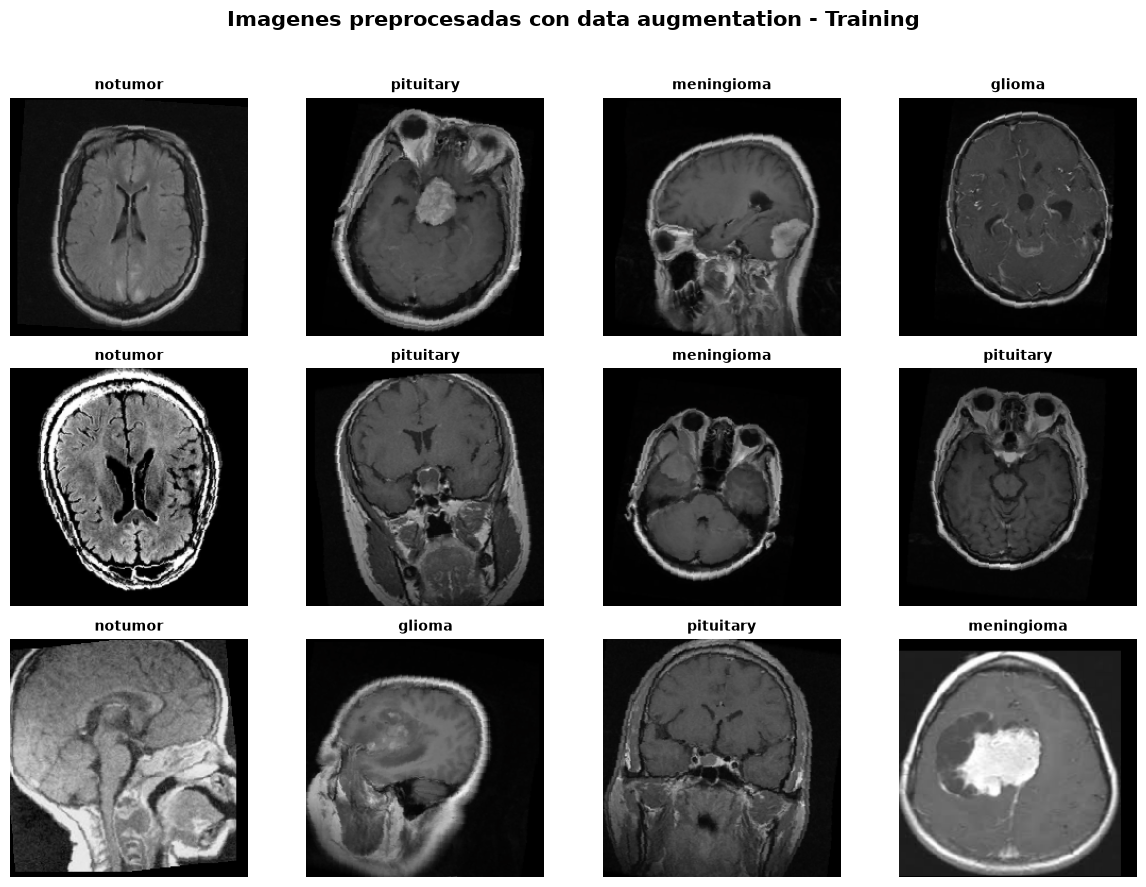

Figura guardada en: c:\Users\admin\Desktop\Maestria en BI y Analisis de Datos\M3\06 - Redes Neuronales y Deep Learning\Proyecto Final\outputs\figures\transfer_resnet18_preprocessed_samples.png


In [10]:
# Paso 11 - Visualizacion de imagenes preprocesadas

def denormalize_image(tensor_image, mean=imagenet_mean, std=imagenet_std):
    image = tensor_image.clone().detach().cpu()

    mean_tensor = torch.tensor(mean).view(3, 1, 1)
    std_tensor = torch.tensor(std).view(3, 1, 1)

    image = image * std_tensor + mean_tensor
    image = image.clamp(0, 1)

    return image.permute(1, 2, 0).numpy()


sample_images, sample_labels = next(iter(train_loader))

num_images_to_show = 12
fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for idx, ax in enumerate(axes.flatten()):
    image = denormalize_image(sample_images[idx])
    label_idx = int(sample_labels[idx])
    class_name = CLASS_NAMES[label_idx]

    ax.imshow(image)
    ax.set_title(class_name, fontsize=10, fontweight="bold")
    ax.axis("off")

plt.suptitle(
    "Imagenes preprocesadas con data augmentation - Training",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

preprocessed_samples_path = FIGURES_DIR / "transfer_resnet18_preprocessed_samples.png"
plt.savefig(preprocessed_samples_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"Figura guardada en: {preprocessed_samples_path}")

### Interpretación de imágenes preprocesadas

La visualización de imágenes preprocesadas confirma que el pipeline funciona correctamente. Todas las imágenes se muestran con tamaño uniforme y conservan una apariencia visual coherente después de aplicar redimensionamiento, conversión a `RGB`, normalización ImageNet y data augmentation.

Las transformaciones aleatorias introducen variaciones moderadas, como ligeras rotaciones, traslaciones o cambios de escala. Estas modificaciones son apropiadas para entrenamiento porque ayudan a mejorar la generalización sin alterar de forma excesiva la estructura anatómica de las imágenes.

Con esta validación, el dataset queda listo para definir el modelo de transfer learning con ResNet18.

## 12. Definición del modelo ResNet18 con transfer learning

En este paso se define el modelo de transfer learning usando ResNet18 preentrenado con ImageNet.

La estrategia inicial será:

1. Cargar ResNet18 con pesos preentrenados.
2. Congelar las capas convolucionales base.
3. Reemplazar la capa final (`fc`) por una cabeza clasificadora adaptada a las cuatro clases del proyecto.
4. Entrenar inicialmente solo la cabeza clasificadora.

Esta estrategia permite aprovechar las características visuales generales aprendidas por ResNet18 y ajustar únicamente la parte final del modelo al problema de clasificación de tumores cerebrales.

Más adelante, si los resultados lo justifican, se podrá hacer fine-tuning parcial descongelando algunas capas finales.

In [11]:
# Paso 12 - Definicion de modelo ResNet18 con transfer learning

weights = ResNet18_Weights.DEFAULT

model = models.resnet18(weights=weights)

for parameter in model.parameters():
    parameter.requires_grad = False

num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(num_features, NUM_CLASSES)
)

model = model.to(DEVICE)

total_params = sum(parameter.numel() for parameter in model.parameters())
trainable_params = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

frozen_params = total_params - trainable_params

print(model)

print(f"\nModelo base: {MODEL_NAME}")
print(f"Pesos preentrenados: {weights}")
print(f"Caracteristicas de entrada a la capa final: {num_features}")
print(f"Numero de clases de salida: {NUM_CLASSES}")

print(f"\nParametros totales: {total_params:,}")
print(f"Parametros congelados: {frozen_params:,}")
print(f"Parametros entrenables: {trainable_params:,}")

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

### Interpretación del modelo ResNet18

El modelo ResNet18 se cargó correctamente con pesos preentrenados de ImageNet (`IMAGENET1K_V1`).

La arquitectura base quedó congelada, por lo que sus capas convolucionales no se actualizarán durante esta primera etapa de entrenamiento. Esto permite aprovechar las características visuales aprendidas previamente y entrenar únicamente la nueva cabeza clasificadora.

La capa final original fue reemplazada por una cabeza adaptada al problema:

- `Dropout(p=0.3)`.
- `Linear(in_features=512, out_features=4)`.

El modelo tiene 11,178,564 parámetros en total. De ellos, 11,176,512 permanecen congelados y solo 2,052 serán entrenables inicialmente.

Esta configuración es adecuada para una primera fase de transfer learning porque reduce el costo computacional y limita el riesgo de sobreajuste.

## 13. Prueba rápida de propagación hacia adelante

Antes de entrenar el modelo, se realiza una prueba rápida con un batch de imágenes. El objetivo es confirmar que ResNet18 recibe correctamente las entradas y genera una salida con la forma esperada.

Para un problema de cuatro clases, la salida del modelo debe tener la forma:

`batch_size x 4`

Cada fila contiene los logits asociados a las cuatro clases. Luego se aplica `softmax` para convertir esos logits en probabilidades.

In [12]:
# Paso 13 - Prueba forward pass con un batch

model.eval()

sample_images, sample_labels = next(iter(train_loader))
sample_images = sample_images.to(DEVICE)
sample_labels = sample_labels.to(DEVICE)

with torch.no_grad():
    sample_outputs = model(sample_images)

print("Forma de entrada:", sample_images.shape)
print("Forma de salida:", sample_outputs.shape)
print("Numero de clases:", NUM_CLASSES)

sample_probabilities = torch.softmax(sample_outputs, dim=1)
sample_predictions = torch.argmax(sample_probabilities, dim=1)

print("\nPrimeras probabilidades:")
print(sample_probabilities[:5].cpu())

print("\nPrimeras predicciones:")
print(sample_predictions[:10].cpu().tolist())

print("\nPrimeras etiquetas reales:")
print(sample_labels[:10].cpu().tolist())

Forma de entrada: torch.Size([32, 3, 224, 224])
Forma de salida: torch.Size([32, 4])
Numero de clases: 4

Primeras probabilidades:
tensor([[0.1182, 0.1005, 0.6531, 0.1283],
        [0.1736, 0.0648, 0.5547, 0.2069],
        [0.0833, 0.0383, 0.7776, 0.1008],
        [0.2563, 0.0714, 0.5446, 0.1277],
        [0.0877, 0.0663, 0.7668, 0.0791]])

Primeras predicciones:
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2]

Primeras etiquetas reales:
[3, 3, 2, 3, 0, 2, 3, 2, 1, 1]


### Interpretación de la prueba forward pass

La prueba de propagación hacia adelante confirma que ResNet18 recibe correctamente un batch de imágenes con forma `[32, 3, 224, 224]` y produce una salida con forma `[32, 4]`.

Esto significa que el modelo genera cuatro logits por imagen, uno para cada clase del problema.

Las probabilidades iniciales no representan todavía un desempeño real del modelo, porque la nueva cabeza clasificadora fue inicializada aleatoriamente y aún no ha sido entrenada con el dataset.

El hecho de que las primeras predicciones sean todas la clase `2` (`notumor`) no representa un problema en esta etapa. Es simplemente el comportamiento inicial del clasificador antes del entrenamiento.

## 14. Configuración de pérdida, optimizador y scheduler

Para entrenar el modelo se define la función de pérdida, el optimizador y un scheduler de tasa de aprendizaje.

Se utilizará:

- `CrossEntropyLoss`: función estándar para clasificación multiclase.
- `Adam`: optimizador robusto y ampliamente usado en redes neuronales.
- `ReduceLROnPlateau`: scheduler que reduce la tasa de aprendizaje cuando la pérdida de validación deja de mejorar.

Como las capas base de ResNet18 están congeladas, el optimizador se configurará para actualizar únicamente los parámetros entrenables de la cabeza clasificadora.

Esta configuración permite entrenar primero una versión liviana del modelo, aprovechando la extracción de características de ResNet18 y ajustando solo la capa final al problema de cuatro clases.

In [13]:
# Paso 14 - Configuracion de perdida, optimizador y scheduler

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda parameter: parameter.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("Funcion de perdida:", criterion)
print("Optimizador:", optimizer)
print("Scheduler:", scheduler)
print(f"Learning rate inicial: {LEARNING_RATE}")
print(f"Weight decay: {WEIGHT_DECAY}")
print(f"Parametros entrenables enviados al optimizador: {trainable_params:,}")

Funcion de perdida: CrossEntropyLoss()
Optimizador: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
Scheduler: <torch.optim.lr_scheduler.ReduceLROnPlateau object at 0x0000023FB34C3590>
Learning rate inicial: 0.001
Weight decay: 0.0001
Parametros entrenables enviados al optimizador: 2,052


## 15. Funciones de entrenamiento y evaluación

Para mantener el notebook organizado, se definen funciones reutilizables para entrenar y evaluar el modelo.

La función de entrenamiento realiza:

- Modo entrenamiento del modelo.
- Forward pass.
- Cálculo de pérdida.
- Backpropagation.
- Actualización de pesos.
- Cálculo de accuracy por época.

La función de evaluación realiza:

- Modo evaluación del modelo.
- Desactivación de gradientes.
- Cálculo de pérdida.
- Cálculo de accuracy.
- Almacenamiento de predicciones y etiquetas reales.
- Almacenamiento de probabilidades por clase.

Estas funciones se reutilizarán tanto para la fase inicial de entrenamiento de la cabeza clasificadora como para una posible fase posterior de fine-tuning parcial.

In [14]:
# Paso 15 - Funciones de entrenamiento y evaluacion

def train_one_epoch(model, data_loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size

        predictions = torch.argmax(outputs, dim=1)
        correct_predictions += (predictions == labels).sum().item()
        total_samples += batch_size

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples

    return epoch_loss, epoch_accuracy


def evaluate_model(model, data_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probabilities = torch.softmax(outputs, dim=1)
            predictions = torch.argmax(probabilities, dim=1)

            batch_size = images.size(0)
            running_loss += loss.item() * batch_size

            correct_predictions += (predictions == labels).sum().item()
            total_samples += batch_size

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples

    return {
        "loss": epoch_loss,
        "accuracy": epoch_accuracy,
        "labels": np.array(all_labels),
        "predictions": np.array(all_predictions),
        "probabilities": np.array(all_probabilities),
    }


print("Funciones de entrenamiento y evaluacion definidas correctamente.")

Funciones de entrenamiento y evaluacion definidas correctamente.


## 16. Entrenamiento inicial de ResNet18 con early stopping

En esta sección se entrena la cabeza clasificadora de ResNet18 usando el conjunto de entrenamiento y se monitorea el desempeño en validación.

Durante esta primera fase, las capas base de ResNet18 permanecen congeladas. Solo se actualizan los parámetros de la nueva capa final adaptada a las cuatro clases del proyecto.

Se utilizará early stopping para detener el entrenamiento si la pérdida de validación deja de mejorar. Esto ayuda a conservar el mejor modelo observado y reduce el riesgo de sobreajuste.

Durante cada época se registrarán:

- Pérdida de entrenamiento.
- Accuracy de entrenamiento.
- Pérdida de validación.
- Accuracy de validación.
- Learning rate actual.

El mejor modelo se guardará en la carpeta `models/`.

In [15]:
# Paso 16 - Entrenamiento inicial de ResNet18 con early stopping

NUM_EPOCHS = 15
EARLY_STOPPING_PATIENCE = 4
MIN_DELTA = 1e-4

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "learning_rate": [],
}

best_val_loss = float("inf")
best_epoch = 0
epochs_without_improvement = 0

training_start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start_time = time.time()

    train_loss, train_accuracy = train_one_epoch(
        model=model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE
    )

    val_results = evaluate_model(
        model=model,
        data_loader=val_loader,
        criterion=criterion,
        device=DEVICE
    )

    val_loss = val_results["loss"]
    val_accuracy = val_results["accuracy"]

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)
    history["learning_rate"].append(current_lr)

    epoch_duration = time.time() - epoch_start_time

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"LR: {current_lr:.6f} | "
        f"Tiempo: {epoch_duration:.1f}s"
    )

    if val_loss < best_val_loss - MIN_DELTA:
        best_val_loss = val_loss
        best_epoch = epoch
        epochs_without_improvement = 0

        checkpoint = {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": epoch,
            "best_val_loss": best_val_loss,
            "class_names": CLASS_NAMES,
            "image_size": IMAGE_SIZE,
            "model_name": MODEL_NAME,
            "imagenet_mean": imagenet_mean,
            "imagenet_std": imagenet_std,
            "history": history,
            "training_phase": "frozen_resnet18_head",
        }

        torch.save(checkpoint, TRANSFER_MODEL_PATH)
        print(f"  Mejor modelo guardado en epoch {epoch} con val_loss={best_val_loss:.4f}")
    else:
        epochs_without_improvement += 1
        print(f"  Sin mejora en validacion: {epochs_without_improvement}/{EARLY_STOPPING_PATIENCE}")

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"\nEarly stopping activado en epoch {epoch}.")
        break

training_total_time = time.time() - training_start_time

print("\nEntrenamiento inicial finalizado.")
print(f"Mejor epoch: {best_epoch}")
print(f"Mejor val_loss: {best_val_loss:.4f}")
print(f"Tiempo total de entrenamiento: {training_total_time / 60:.2f} minutos")
print(f"Checkpoint guardado en: {TRANSFER_MODEL_PATH}")

Epoch 01/15 | Train Loss: 0.8660 | Train Acc: 0.6571 | Val Loss: 0.5878 | Val Acc: 0.8027 | LR: 0.001000 | Tiempo: 213.9s
  Mejor modelo guardado en epoch 1 con val_loss=0.5878
Epoch 02/15 | Train Loss: 0.5658 | Train Acc: 0.7877 | Val Loss: 0.4744 | Val Acc: 0.8179 | LR: 0.001000 | Tiempo: 196.8s
  Mejor modelo guardado en epoch 2 con val_loss=0.4744
Epoch 03/15 | Train Loss: 0.5191 | Train Acc: 0.8089 | Val Loss: 0.4066 | Val Acc: 0.8527 | LR: 0.001000 | Tiempo: 192.8s
  Mejor modelo guardado en epoch 3 con val_loss=0.4066
Epoch 04/15 | Train Loss: 0.4869 | Train Acc: 0.8181 | Val Loss: 0.3918 | Val Acc: 0.8589 | LR: 0.001000 | Tiempo: 240.6s
  Mejor modelo guardado en epoch 4 con val_loss=0.3918
Epoch 05/15 | Train Loss: 0.4596 | Train Acc: 0.8237 | Val Loss: 0.3823 | Val Acc: 0.8643 | LR: 0.001000 | Tiempo: 196.6s
  Mejor modelo guardado en epoch 5 con val_loss=0.3823
Epoch 06/15 | Train Loss: 0.4715 | Train Acc: 0.8208 | Val Loss: 0.3547 | Val Acc: 0.8688 | LR: 0.001000 | Tiempo: 

### Interpretación del entrenamiento inicial de ResNet18

El entrenamiento inicial de ResNet18 finalizó correctamente. La mejor época registrada fue la época 15, con una pérdida de validación de `0.3201`.

El hecho de que la mejor época haya sido la última sugiere que el modelo todavía podía seguir mejorando al finalizar las 15 épocas configuradas. Esto no representa un error; más bien indica que la cabeza clasificadora continuaba aprendiendo patrones útiles del dataset.

El tiempo total de entrenamiento fue de 51.09 minutos. El mejor checkpoint quedó guardado en la ruta definida para el modelo de transfer learning.

Antes de decidir si se entrenan más épocas o si se realiza fine-tuning parcial, es conveniente revisar las curvas de pérdida y accuracy.

## 17. Curvas de entrenamiento y validación

En este paso se visualizan las curvas registradas durante el entrenamiento inicial de ResNet18.

Se revisarán:

- Pérdida de entrenamiento.
- Pérdida de validación.
- Accuracy de entrenamiento.
- Accuracy de validación.
- Evolución del learning rate.

Estas curvas permiten analizar si el modelo está aprendiendo de forma estable, si existe sobreajuste y si podría beneficiarse de más épocas o de una fase posterior de fine-tuning parcial.

,train_loss,train_accuracy,val_loss,val_accuracy,learning_rate,epoch
0,0.865980,0.657143,0.587756,0.802679,0.0010,1
1,0.565759,0.787723,0.474396,0.817857,0.0010,2
2,0.519115,0.808929,0.406632,0.852679,0.0010,3
3,0.486918,0.818080,0.391757,0.858929,0.0010,4
4,0.459646,0.823661,0.382252,0.864286,0.0010,5
5,0.471500,0.820759,0.354702,0.868750,0.0010,6
6,0.478922,0.816741,0.373500,0.864286,0.0010,7
7,0.463223,0.822098,0.362670,0.867857,0.0010,8
8,0.450727,0.833036,0.341400,0.874107,0.0010,9
9,0.444226,0.827679,0.350711,0.876786,0.0010,10


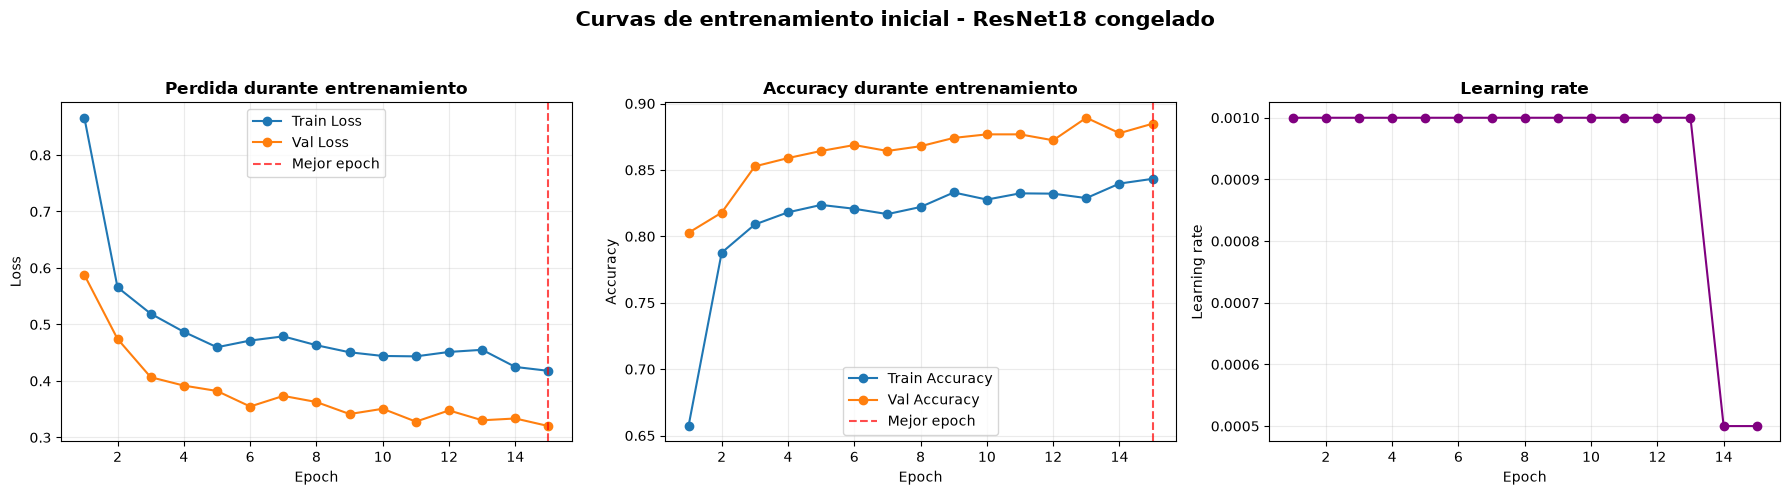

Mejor epoch segun val_loss: 15
Mejor val_loss: 0.3201
Figura guardada en: c:\Users\admin\Desktop\Maestria en BI y Analisis de Datos\M3\06 - Redes Neuronales y Deep Learning\Proyecto Final\outputs\figures\transfer_resnet18_training_curves.png


In [16]:
# Paso 17 - Visualizacion de curvas de entrenamiento

history_df = pd.DataFrame(history)
history_df["epoch"] = range(1, len(history_df) + 1)

display(history_df)

best_epoch_from_history = int(history_df.loc[history_df["val_loss"].idxmin(), "epoch"])
best_val_loss_from_history = float(history_df["val_loss"].min())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val Loss")
axes[0].axvline(best_epoch_from_history, color="red", linestyle="--", alpha=0.7, label="Mejor epoch")
axes[0].set_title("Perdida durante entrenamiento", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(history_df["epoch"], history_df["train_accuracy"], marker="o", label="Train Accuracy")
axes[1].plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="Val Accuracy")
axes[1].axvline(best_epoch_from_history, color="red", linestyle="--", alpha=0.7, label="Mejor epoch")
axes[1].set_title("Accuracy durante entrenamiento", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.25)

axes[2].plot(history_df["epoch"], history_df["learning_rate"], marker="o", color="purple")
axes[2].set_title("Learning rate", fontweight="bold")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Learning rate")
axes[2].grid(alpha=0.25)

plt.suptitle(
    "Curvas de entrenamiento inicial - ResNet18 congelado",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(TRANSFER_CURVES_PATH, dpi=150, bbox_inches="tight")
plt.show()

print(f"Mejor epoch segun val_loss: {best_epoch_from_history}")
print(f"Mejor val_loss: {best_val_loss_from_history:.4f}")
print(f"Figura guardada en: {TRANSFER_CURVES_PATH}")

### Interpretación de las curvas de entrenamiento

Las curvas muestran que ResNet18 congelado aprendió de forma estable durante las 15 épocas.

La pérdida de validación bajó desde `0.5878` hasta `0.3201`, y la mejor época fue la última. Esto sugiere que el modelo aún podía seguir mejorando al finalizar el entrenamiento inicial.

La accuracy de validación alcanzó valores cercanos a `0.88 - 0.89`, con un máximo observado de `0.8893` en la época 13 y `0.8848` en la época 15. No se observa un sobreajuste severo, ya que la accuracy de validación se mantiene por encima de la accuracy de entrenamiento en varias épocas.

El scheduler redujo el learning rate de `0.001` a `0.0005` en las últimas épocas, lo cual ayudó a continuar ajustando el modelo con pasos más pequeños.

Dado que la mejor pérdida de validación ocurrió en la última época, conviene realizar una fase corta de fine-tuning parcial, descongelando únicamente las últimas capas de ResNet18 con una tasa de aprendizaje baja.

## 18. Fine-tuning parcial de ResNet18

Después del entrenamiento inicial de la cabeza clasificadora, se realizará una fase corta de fine-tuning parcial.

En esta fase se descongelará únicamente el bloque final de ResNet18 (`layer4`) junto con la cabeza clasificadora (`fc`). Las capas anteriores permanecerán congeladas.

Esta estrategia permite adaptar características más específicas del modelo al dataset de resonancias cerebrales, manteniendo bajo control el riesgo de sobreajuste y el costo computacional.

Se utilizarán tasas de aprendizaje pequeñas:

- `layer4`: learning rate bajo para ajustar suavemente las características profundas.
- `fc`: learning rate un poco mayor para seguir adaptando la cabeza clasificadora.

El checkpoint se actualizará solo si mejora la pérdida de validación respecto al mejor modelo guardado previamente.

In [17]:
# Paso 18 - Fine-tuning parcial de ResNet18

checkpoint = torch.load(TRANSFER_MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])

best_val_loss = checkpoint["best_val_loss"]
best_epoch_initial = checkpoint["epoch"]

print(f"Checkpoint cargado desde: {TRANSFER_MODEL_PATH}")
print(f"Mejor val_loss previo: {best_val_loss:.4f}")
print(f"Mejor epoch previo: {best_epoch_initial}")

for parameter in model.parameters():
    parameter.requires_grad = False

for parameter in model.layer4.parameters():
    parameter.requires_grad = True

for parameter in model.fc.parameters():
    parameter.requires_grad = True

fine_tune_trainable_params = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(f"\nParametros entrenables durante fine-tuning: {fine_tune_trainable_params:,}")

FINE_TUNE_EPOCHS = 5
FINE_TUNE_PATIENCE = 3
FINE_TUNE_MIN_DELTA = 1e-4

fine_tune_optimizer = optim.Adam(
    [
        {"params": model.layer4.parameters(), "lr": 1e-5},
        {"params": model.fc.parameters(), "lr": 1e-4},
    ],
    weight_decay=WEIGHT_DECAY
)

fine_tune_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    fine_tune_optimizer,
    mode="min",
    factor=0.5,
    patience=1
)

fine_tune_history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "layer4_learning_rate": [],
    "fc_learning_rate": [],
}

epochs_without_improvement = 0
fine_tuning_start_time = time.time()

for epoch in range(1, FINE_TUNE_EPOCHS + 1):
    epoch_start_time = time.time()

    train_loss, train_accuracy = train_one_epoch(
        model=model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=fine_tune_optimizer,
        device=DEVICE
    )

    val_results = evaluate_model(
        model=model,
        data_loader=val_loader,
        criterion=criterion,
        device=DEVICE
    )

    val_loss = val_results["loss"]
    val_accuracy = val_results["accuracy"]

    fine_tune_scheduler.step(val_loss)

    layer4_lr = fine_tune_optimizer.param_groups[0]["lr"]
    fc_lr = fine_tune_optimizer.param_groups[1]["lr"]

    fine_tune_history["train_loss"].append(train_loss)
    fine_tune_history["train_accuracy"].append(train_accuracy)
    fine_tune_history["val_loss"].append(val_loss)
    fine_tune_history["val_accuracy"].append(val_accuracy)
    fine_tune_history["layer4_learning_rate"].append(layer4_lr)
    fine_tune_history["fc_learning_rate"].append(fc_lr)

    epoch_duration = time.time() - epoch_start_time

    print(
        f"Fine-tuning Epoch {epoch:02d}/{FINE_TUNE_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"LR layer4: {layer4_lr:.6f} | "
        f"LR fc: {fc_lr:.6f} | "
        f"Tiempo: {epoch_duration:.1f}s"
    )

    if val_loss < best_val_loss - FINE_TUNE_MIN_DELTA:
        best_val_loss = val_loss
        epochs_without_improvement = 0

        checkpoint = {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": fine_tune_optimizer.state_dict(),
            "epoch": epoch,
            "best_val_loss": best_val_loss,
            "class_names": CLASS_NAMES,
            "image_size": IMAGE_SIZE,
            "model_name": MODEL_NAME,
            "imagenet_mean": imagenet_mean,
            "imagenet_std": imagenet_std,
            "history": history,
            "fine_tune_history": fine_tune_history,
            "training_phase": "partial_fine_tuning_layer4",
        }

        torch.save(checkpoint, TRANSFER_MODEL_PATH)
        print(f"  Mejor modelo actualizado en fine-tuning epoch {epoch} con val_loss={best_val_loss:.4f}")
    else:
        epochs_without_improvement += 1
        print(f"  Sin mejora en validacion: {epochs_without_improvement}/{FINE_TUNE_PATIENCE}")

    if epochs_without_improvement >= FINE_TUNE_PATIENCE:
        print(f"\nEarly stopping de fine-tuning activado en epoch {epoch}.")
        break

fine_tuning_total_time = time.time() - fine_tuning_start_time

print("\nFine-tuning finalizado.")
print(f"Mejor val_loss global: {best_val_loss:.4f}")
print(f"Tiempo total de fine-tuning: {fine_tuning_total_time / 60:.2f} minutos")
print(f"Checkpoint final guardado en: {TRANSFER_MODEL_PATH}")

Checkpoint cargado desde: c:\Users\admin\Desktop\Maestria en BI y Analisis de Datos\M3\06 - Redes Neuronales y Deep Learning\Proyecto Final\models\transfer_resnet18.pth
Mejor val_loss previo: 0.3201
Mejor epoch previo: 15

Parametros entrenables durante fine-tuning: 8,395,780
Fine-tuning Epoch 01/5 | Train Loss: 0.4035 | Train Acc: 0.8500 | Val Loss: 0.2582 | Val Acc: 0.9071 | LR layer4: 0.000010 | LR fc: 0.000100 | Tiempo: 239.1s
  Mejor modelo actualizado en fine-tuning epoch 1 con val_loss=0.2582
Fine-tuning Epoch 02/5 | Train Loss: 0.3185 | Train Acc: 0.8835 | Val Loss: 0.2262 | Val Acc: 0.9179 | LR layer4: 0.000010 | LR fc: 0.000100 | Tiempo: 243.8s
  Mejor modelo actualizado en fine-tuning epoch 2 con val_loss=0.2262
Fine-tuning Epoch 03/5 | Train Loss: 0.2783 | Train Acc: 0.8949 | Val Loss: 0.2084 | Val Acc: 0.9179 | LR layer4: 0.000010 | LR fc: 0.000100 | Tiempo: 243.3s
  Mejor modelo actualizado en fine-tuning epoch 3 con val_loss=0.2084
Fine-tuning Epoch 04/5 | Train Loss: 0.

### Interpretación del fine-tuning parcial

El fine-tuning parcial de ResNet18 finalizó correctamente y produjo una mejora importante respecto al entrenamiento inicial.

Antes del fine-tuning, el mejor `val_loss` era `0.3201`. Después de descongelar `layer4` y continuar entrenando la cabeza clasificadora, el mejor `val_loss` bajó hasta `0.1702`.

La accuracy de validación también mejoró, pasando de valores cercanos a `0.88 - 0.89` durante la fase inicial a `0.9393` en la última época de fine-tuning.

Esto indica que adaptar parcialmente las capas profundas de ResNet18 al dataset de resonancias cerebrales ayudó al modelo a aprender características más específicas del problema.

La mejor época volvió a ser la última, pero la mejora ya es sustancial. Para evitar optimizar demasiado sobre validación, primero se revisarán las curvas completas y luego se continuará con la evaluación final sobre `Testing/`.

## 19. Curvas completas de entrenamiento y fine-tuning

En este paso se visualizan de forma conjunta las métricas del entrenamiento inicial y del fine-tuning parcial.

Se revisarán:

- Pérdida de entrenamiento.
- Pérdida de validación.
- Accuracy de entrenamiento.
- Accuracy de validación.
- Cambio entre la fase congelada y la fase de fine-tuning.

Esta visualización permite documentar el impacto del fine-tuning y guardar las curvas finales del modelo transfer learning.

,global_epoch,epoch,phase,train_loss,train_accuracy,val_loss,val_accuracy,learning_rate
0,1,1,ResNet18 congelado,0.865980,0.657143,0.587756,0.802679,0.0010
1,2,2,ResNet18 congelado,0.565759,0.787723,0.474396,0.817857,0.0010
2,3,3,ResNet18 congelado,0.519115,0.808929,0.406632,0.852679,0.0010
3,4,4,ResNet18 congelado,0.486918,0.818080,0.391757,0.858929,0.0010
4,5,5,ResNet18 congelado,0.459646,0.823661,0.382252,0.864286,0.0010
5,6,6,ResNet18 congelado,0.471500,0.820759,0.354702,0.868750,0.0010
6,7,7,ResNet18 congelado,0.478922,0.816741,0.373500,0.864286,0.0010
7,8,8,ResNet18 congelado,0.463223,0.822098,0.362670,0.867857,0.0010
8,9,9,ResNet18 congelado,0.450727,0.833036,0.341400,0.874107,0.0010
9,10,10,ResNet18 congelado,0.444226,0.827679,0.350711,0.876786,0.0010


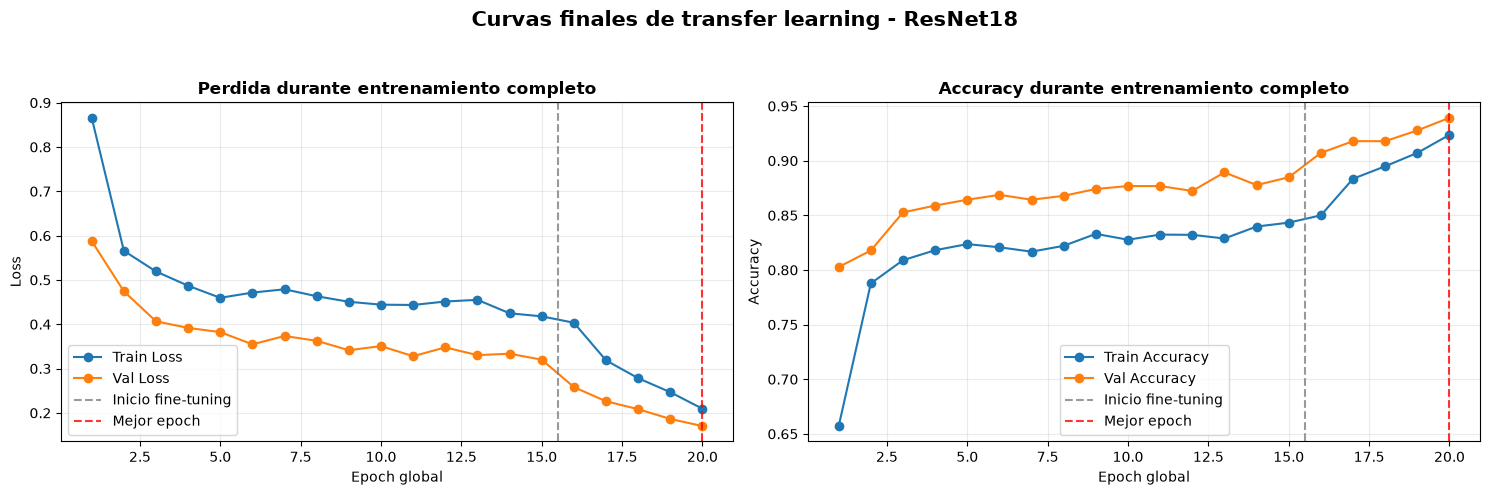

Mejor epoch global segun val_loss: 20
Mejor val_loss final: 0.1702
Figura final guardada en: c:\Users\admin\Desktop\Maestria en BI y Analisis de Datos\M3\06 - Redes Neuronales y Deep Learning\Proyecto Final\outputs\figures\transfer_resnet18_training_curves.png


In [18]:
# Paso 19 - Curvas completas de entrenamiento y fine-tuning

initial_history_df = pd.DataFrame(history)
initial_history_df["epoch"] = range(1, len(initial_history_df) + 1)
initial_history_df["global_epoch"] = initial_history_df["epoch"]
initial_history_df["phase"] = "ResNet18 congelado"

fine_tune_history_df = pd.DataFrame(fine_tune_history)
fine_tune_history_df["epoch"] = range(1, len(fine_tune_history_df) + 1)
fine_tune_history_df["global_epoch"] = len(initial_history_df) + fine_tune_history_df["epoch"]
fine_tune_history_df["phase"] = "Fine-tuning layer4"

fine_tune_history_df["learning_rate"] = fine_tune_history_df["fc_learning_rate"]

combined_history_df = pd.concat(
    [
        initial_history_df[[
            "global_epoch",
            "epoch",
            "phase",
            "train_loss",
            "train_accuracy",
            "val_loss",
            "val_accuracy",
            "learning_rate"
        ]],
        fine_tune_history_df[[
            "global_epoch",
            "epoch",
            "phase",
            "train_loss",
            "train_accuracy",
            "val_loss",
            "val_accuracy",
            "learning_rate"
        ]]
    ],
    ignore_index=True
)

display(combined_history_df)

best_global_epoch = int(combined_history_df.loc[combined_history_df["val_loss"].idxmin(), "global_epoch"])
best_val_loss_combined = float(combined_history_df["val_loss"].min())

fine_tuning_start_epoch = len(initial_history_df) + 0.5

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(combined_history_df["global_epoch"], combined_history_df["train_loss"], marker="o", label="Train Loss")
axes[0].plot(combined_history_df["global_epoch"], combined_history_df["val_loss"], marker="o", label="Val Loss")
axes[0].axvline(fine_tuning_start_epoch, color="gray", linestyle="--", alpha=0.8, label="Inicio fine-tuning")
axes[0].axvline(best_global_epoch, color="red", linestyle="--", alpha=0.8, label="Mejor epoch")
axes[0].set_title("Perdida durante entrenamiento completo", fontweight="bold")
axes[0].set_xlabel("Epoch global")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(combined_history_df["global_epoch"], combined_history_df["train_accuracy"], marker="o", label="Train Accuracy")
axes[1].plot(combined_history_df["global_epoch"], combined_history_df["val_accuracy"], marker="o", label="Val Accuracy")
axes[1].axvline(fine_tuning_start_epoch, color="gray", linestyle="--", alpha=0.8, label="Inicio fine-tuning")
axes[1].axvline(best_global_epoch, color="red", linestyle="--", alpha=0.8, label="Mejor epoch")
axes[1].set_title("Accuracy durante entrenamiento completo", fontweight="bold")
axes[1].set_xlabel("Epoch global")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.suptitle(
    "Curvas finales de transfer learning - ResNet18",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(TRANSFER_CURVES_PATH, dpi=150, bbox_inches="tight")
plt.show()

print(f"Mejor epoch global segun val_loss: {best_global_epoch}")
print(f"Mejor val_loss final: {best_val_loss_combined:.4f}")
print(f"Figura final guardada en: {TRANSFER_CURVES_PATH}")

### Interpretación de las curvas completas de entrenamiento y fine-tuning

Las curvas finales muestran una mejora clara después de iniciar el fine-tuning parcial.

Durante la fase con ResNet18 congelado, el modelo ya alcanzaba un desempeño sólido. Sin embargo, al descongelar `layer4` y continuar entrenando con tasas de aprendizaje bajas, la pérdida de validación siguió disminuyendo de forma sostenida.

El mejor resultado se obtuvo en la época global 20, con un `val_loss` final de `0.1702`. La accuracy de validación también aumentó hasta aproximadamente `0.9393`.

Esto confirma que el fine-tuning parcial aportó una mejora relevante frente al entrenamiento de solo la cabeza clasificadora. Con estas curvas, el modelo queda listo para evaluarse sobre el conjunto `Testing/`, que no ha sido usado durante entrenamiento ni validación.

## 20. Evaluación final del modelo transfer learning sobre Testing

Una vez cargado el mejor checkpoint, se evalúa el modelo sobre el conjunto `Testing/`.

Este conjunto no fue utilizado durante el entrenamiento ni durante la validación, por lo que permite estimar el desempeño final del modelo sobre datos no vistos.

Se calcularán las siguientes métricas:

- Loss en Testing.
- Accuracy global.
- Precision macro.
- Recall macro.
- F1-score macro.
- Reporte de clasificación por clase.

Estas métricas se compararán más adelante contra los resultados de la CNN baseline.

In [19]:
# Paso 20 - Evaluacion final sobre Testing

checkpoint = torch.load(TRANSFER_MODEL_PATH, map_location=DEVICE)

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)

best_val_loss = checkpoint["best_val_loss"]
training_phase = checkpoint.get("training_phase", "unknown")

print(f"Mejor checkpoint cargado desde: {TRANSFER_MODEL_PATH}")
print(f"Mejor val_loss: {best_val_loss:.4f}")
print(f"Fase del checkpoint: {training_phase}")

test_results = evaluate_model(
    model=model,
    data_loader=test_loader,
    criterion=criterion,
    device=DEVICE
)

test_labels = test_results["labels"]
test_predictions = test_results["predictions"]
test_probabilities = test_results["probabilities"]

test_accuracy = accuracy_score(test_labels, test_predictions)

test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
    test_labels,
    test_predictions,
    average="macro",
    zero_division=0
)

print("\nResultados finales en Testing")
print(f"Test Loss: {test_results['loss']:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision Macro: {test_precision:.4f}")
print(f"Test Recall Macro: {test_recall:.4f}")
print(f"Test F1 Macro: {test_f1:.4f}")

print("\nReporte de clasificacion:")
print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

Mejor checkpoint cargado desde: c:\Users\admin\Desktop\Maestria en BI y Analisis de Datos\M3\06 - Redes Neuronales y Deep Learning\Proyecto Final\models\transfer_resnet18.pth
Mejor val_loss: 0.1702
Fase del checkpoint: partial_fine_tuning_layer4

Resultados finales en Testing
Test Loss: 0.4356
Test Accuracy: 0.8812
Test Precision Macro: 0.8895
Test Recall Macro: 0.8813
Test F1 Macro: 0.8787

Reporte de clasificacion:
              precision    recall  f1-score   support

      glioma       0.97      0.71      0.82       400
  meningioma       0.79      0.85      0.82       400
     notumor       0.85      0.99      0.92       400
   pituitary       0.95      0.97      0.96       400

    accuracy                           0.88      1600
   macro avg       0.89      0.88      0.88      1600
weighted avg       0.89      0.88      0.88      1600



### Interpretación de la evaluación en Testing

El modelo transfer learning con ResNet18 obtuvo un desempeño final sólido sobre el conjunto `Testing`.

Las métricas principales fueron:

- Test Loss: `0.4356`
- Test Accuracy: `0.8812`
- Test Precision Macro: `0.8895`
- Test Recall Macro: `0.8813`
- Test F1 Macro: `0.8787`

Estos resultados superan claramente al baseline CNN, que había obtenido una accuracy de `0.7931` y un F1 macro de `0.7860`.

Por clase, el mejor desempeño se observa en `pituitary`, con F1-score de `0.96`, y en `notumor`, con F1-score de `0.92`. La clase `glioma` presenta una precisión muy alta de `0.97`, pero un recall menor de `0.71`, lo que indica que cuando el modelo predice `glioma` suele acertar, aunque todavía deja sin detectar algunos casos reales de esa clase.

La clase `meningioma` obtiene un F1-score de `0.82`, mejorando respecto al baseline, aunque sigue siendo una clase con cierta dificultad por su posible similitud visual con otros tumores.

En conjunto, la evaluación confirma que transfer learning con fine-tuning parcial mejoró el desempeño general del proyecto.

## 21. Matriz de confusión del modelo transfer learning

La matriz de confusión permite analizar con mayor detalle los aciertos y errores del modelo por clase.

En las filas se muestran las clases reales y en las columnas las clases predichas. Los valores de la diagonal principal representan predicciones correctas, mientras que los valores fuera de la diagonal muestran confusiones entre clases.

Esta matriz ayudará a identificar en qué clases el modelo transfer learning mejora frente al baseline y en cuáles todavía mantiene errores relevantes.

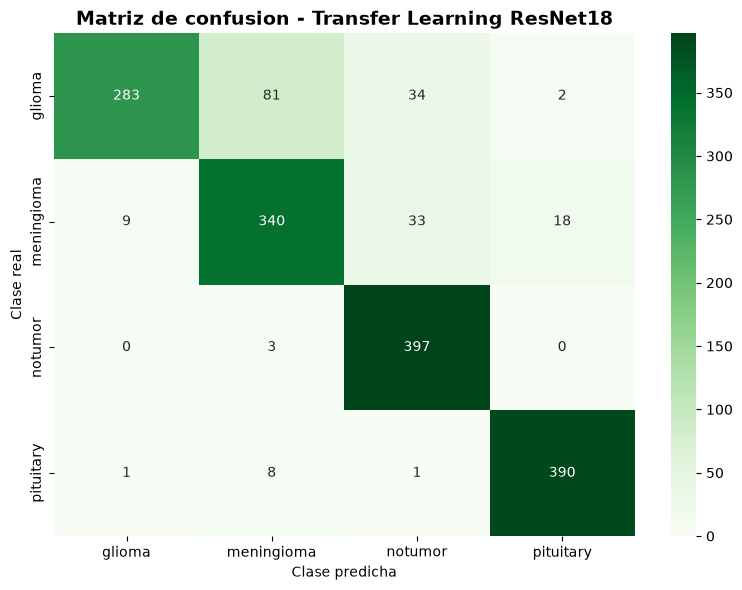

Matriz de confusion guardada en: c:\Users\admin\Desktop\Maestria en BI y Analisis de Datos\M3\06 - Redes Neuronales y Deep Learning\Proyecto Final\outputs\figures\transfer_resnet18_confusion_matrix.png


,pred_glioma,pred_meningioma,pred_notumor,pred_pituitary
real_glioma,283,81,34,2
real_meningioma,9,340,33,18
real_notumor,0,3,397,0
real_pituitary,1,8,1,390


In [20]:
# Paso 21 - Matriz de confusion del modelo transfer learning

conf_matrix = confusion_matrix(
    test_labels,
    test_predictions,
    labels=list(range(NUM_CLASSES))
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title("Matriz de confusion - Transfer Learning ResNet18", fontsize=14, fontweight="bold")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.tight_layout()

confusion_matrix_path = TRANSFER_CONFUSION_MATRIX_PATH
plt.savefig(confusion_matrix_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"Matriz de confusion guardada en: {confusion_matrix_path}")

conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=[f"real_{class_name}" for class_name in CLASS_NAMES],
    columns=[f"pred_{class_name}" for class_name in CLASS_NAMES]
)

display(conf_matrix_df)

### Interpretación de la matriz de confusión

La matriz de confusión confirma que el modelo transfer learning identifica con alta precisión las clases `notumor` y `pituitary`.

Para la clase `notumor`, el modelo clasificó correctamente 397 de 400 imágenes. Solo 3 imágenes fueron confundidas con `meningioma`. Esto indica una capacidad muy alta para reconocer imágenes sin tumor dentro del conjunto de prueba.

Para la clase `pituitary`, el modelo clasificó correctamente 390 de 400 imágenes. Los errores fueron pocos y se distribuyeron principalmente hacia `meningioma`.

La clase `meningioma` también muestra una mejora sólida, con 340 de 400 imágenes clasificadas correctamente. Sus principales confusiones fueron con `notumor` y `pituitary`.

La principal dificultad permanece en la clase `glioma`, donde 283 de 400 imágenes fueron clasificadas correctamente. El error más frecuente fue confundir `glioma` con `meningioma`, con 81 casos. Esto sugiere que visualmente estas dos clases siguen siendo las más difíciles de separar para el modelo.

En conjunto, la matriz muestra una mejora importante frente al baseline, especialmente en la reducción de errores para `meningioma` y en el desempeño general del modelo.

## 22. Guardado de métricas finales del modelo transfer learning

Para facilitar la comparación posterior con la CNN baseline, se guardan las métricas principales del modelo transfer learning en un archivo JSON.

También se guarda la matriz de confusión en formato CSV para conservar una versión tabular de los errores y aciertos por clase.

Los artefactos principales de este modelo son:

- Checkpoint del modelo.
- Métricas finales en Testing.
- Curvas de entrenamiento y fine-tuning.
- Matriz de confusión en imagen.
- Matriz de confusión en CSV.

In [21]:
# Paso 22 - Guardado de metricas finales del modelo transfer learning

transfer_metrics = {
    "model_name": "transfer_resnet18",
    "architecture": MODEL_NAME,
    "training_phase": training_phase,
    "best_val_loss": float(best_val_loss),
    "test_loss": float(test_results["loss"]),
    "test_accuracy": float(test_accuracy),
    "test_precision_macro": float(test_precision),
    "test_recall_macro": float(test_recall),
    "test_f1_macro": float(test_f1),
    "class_names": CLASS_NAMES,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "learning_rate_initial": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "num_train_images": len(train_subset_aug),
    "num_val_images": len(val_subset_eval),
    "num_test_images": len(test_dataset),
    "model_path": str(TRANSFER_MODEL_PATH),
    "confusion_matrix_path": str(TRANSFER_CONFUSION_MATRIX_PATH),
    "training_curves_path": str(TRANSFER_CURVES_PATH),
}

transfer_confusion_matrix_csv_path = METRICS_DIR / "transfer_resnet18_confusion_matrix.csv"

with open(TRANSFER_METRICS_PATH, "w", encoding="utf-8") as file:
    json.dump(transfer_metrics, file, indent=4)

conf_matrix_df.to_csv(transfer_confusion_matrix_csv_path, index=True)

print(f"Metricas guardadas en: {TRANSFER_METRICS_PATH}")
print(f"Matriz de confusion CSV guardada en: {transfer_confusion_matrix_csv_path}")

display(pd.DataFrame([transfer_metrics]))

Metricas guardadas en: c:\Users\admin\Desktop\Maestria en BI y Analisis de Datos\M3\06 - Redes Neuronales y Deep Learning\Proyecto Final\outputs\metrics\transfer_resnet18_metrics.json
Matriz de confusion CSV guardada en: c:\Users\admin\Desktop\Maestria en BI y Analisis de Datos\M3\06 - Redes Neuronales y Deep Learning\Proyecto Final\outputs\metrics\transfer_resnet18_confusion_matrix.csv


,model_name,architecture,training_phase,best_val_loss,test_loss,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,class_names,image_size,batch_size,learning_rate_initial,weight_decay,num_train_images,num_val_images,num_test_images,model_path,confusion_matrix_path,training_curves_path
0,transfer_resnet18,resnet18,partial_fine_tuning_layer4,0.170238,0.435632,0.88125,0.889473,0.88125,0.878732,"[glioma, meningioma, notumor, pituitary]",224,32,0.001,0.0001,4480,1120,1600,c:\Users\admin\Desktop\Maestria en BI y Analis...,c:\Users\admin\Desktop\Maestria en BI y Analis...,c:\Users\admin\Desktop\Maestria en BI y Analis...


## 23. Inferencia sobre 10 imágenes representativas

En este paso se ejecuta inferencia sobre una muestra de 10 imágenes del conjunto `Testing/`.

La muestra se toma de forma balanceada entre las cuatro clases para revisar predicciones individuales del modelo transfer learning.

Para cada imagen se mostrará:

- Imagen original.
- Clase real.
- Clase predicha.
- Confianza de la predicción.

Esta revisión permite observar ejemplos concretos de aciertos y errores del modelo, complementando las métricas globales y la matriz de confusión.

,file_name,image_path,true_class,predicted_class,confidence,is_correct
0,Te-gl_2.jpg,c:\Users\admin\Desktop\Maestria en BI y Analis...,glioma,glioma,0.711734,True
1,Te-gl_206.jpg,c:\Users\admin\Desktop\Maestria en BI y Analis...,glioma,glioma,0.999606,True
2,Te-gl_331.jpg,c:\Users\admin\Desktop\Maestria en BI y Analis...,glioma,glioma,0.968571,True
3,Te-me_284.jpg,c:\Users\admin\Desktop\Maestria en BI y Analis...,meningioma,meningioma,0.820545,True
4,Te-aug-me_18.jpg,c:\Users\admin\Desktop\Maestria en BI y Analis...,meningioma,meningioma,0.986349,True
5,Te-me_265.jpg,c:\Users\admin\Desktop\Maestria en BI y Analis...,meningioma,meningioma,0.859923,True
6,Te-no_190.jpg,c:\Users\admin\Desktop\Maestria en BI y Analis...,notumor,notumor,0.986619,True
7,Te-no_69.jpg,c:\Users\admin\Desktop\Maestria en BI y Analis...,notumor,notumor,0.999970,True
8,Te-pi_399.jpg,c:\Users\admin\Desktop\Maestria en BI y Analis...,pituitary,pituitary,0.990766,True
9,Te-pi_62.jpg,c:\Users\admin\Desktop\Maestria en BI y Analis...,pituitary,pituitary,0.993626,True


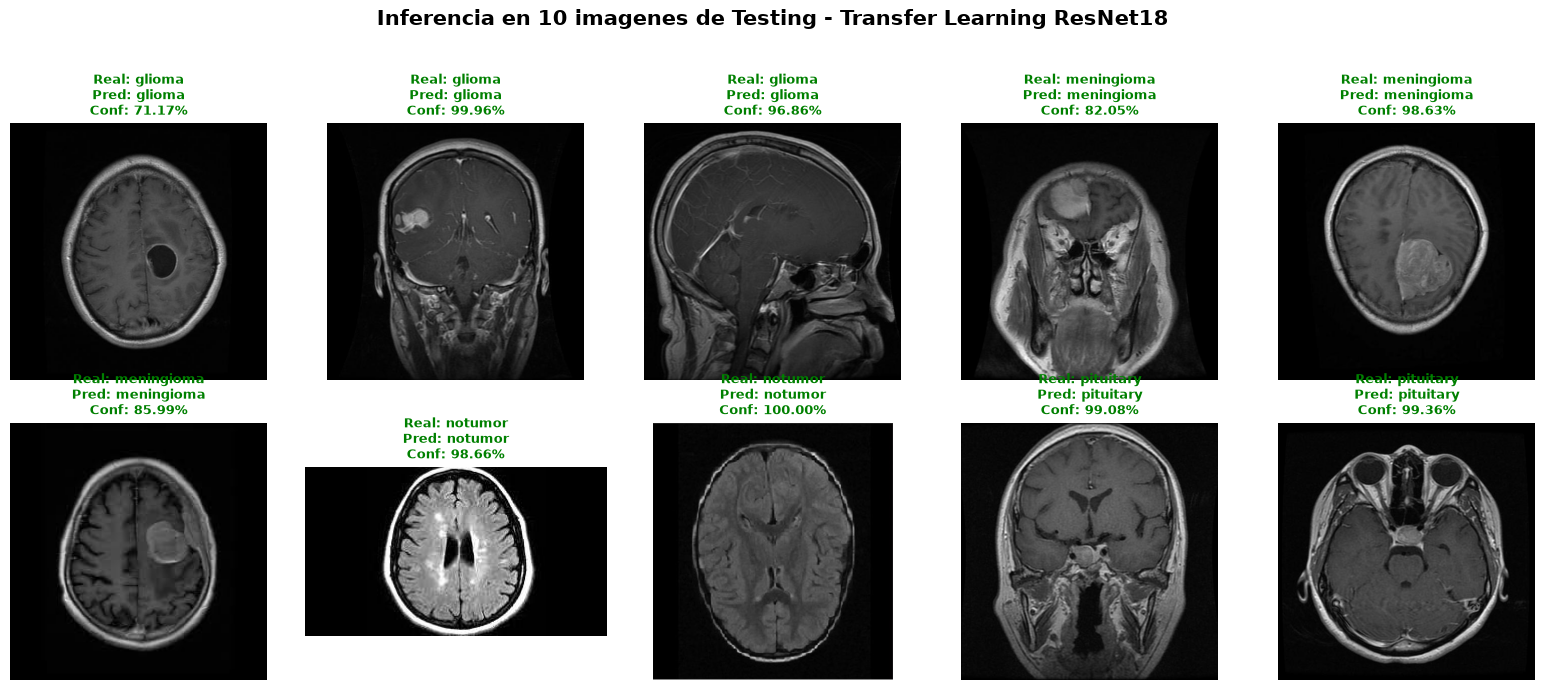

Figura de inferencia guardada en: c:\Users\admin\Desktop\Maestria en BI y Analisis de Datos\M3\06 - Redes Neuronales y Deep Learning\Proyecto Final\outputs\figures\transfer_resnet18_inference_10_samples.png
Resultados de inferencia guardados en: c:\Users\admin\Desktop\Maestria en BI y Analisis de Datos\M3\06 - Redes Neuronales y Deep Learning\Proyecto Final\outputs\metrics\transfer_resnet18_inference_10_samples.csv
Aciertos en muestra: 10/10


In [22]:
# Paso 23 - Inferencia sobre 10 imagenes representativas

def collect_sample_image_paths(test_dir: Path, class_names, total_samples=10):
    samples = []
    valid_extensions = {".jpg", ".jpeg", ".png"}

    base_samples_per_class = total_samples // len(class_names)
    extra_samples = total_samples % len(class_names)

    for class_idx, class_name in enumerate(class_names):
        class_dir = test_dir / class_name
        image_files = sorted([
            file
            for file in class_dir.iterdir()
            if file.suffix.lower() in valid_extensions
        ])

        samples_to_take = base_samples_per_class + (1 if class_idx < extra_samples else 0)
        selected_files = random.sample(image_files, samples_to_take)

        for image_path in selected_files:
            samples.append({
                "image_path": image_path,
                "true_class": class_name,
                "true_label": class_idx,
            })

    return samples


def predict_single_image(model, image_path: Path, transform, class_names, device):
    model.eval()

    original_image = Image.open(image_path)
    input_tensor = transform(original_image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = torch.softmax(outputs, dim=1)[0]
        predicted_label = int(torch.argmax(probabilities).item())
        confidence = float(probabilities[predicted_label].item())

    return {
        "predicted_label": predicted_label,
        "predicted_class": class_names[predicted_label],
        "confidence": confidence,
        "probabilities": probabilities.cpu().numpy(),
    }


inference_samples = collect_sample_image_paths(
    test_dir=TEST_DIR,
    class_names=CLASS_NAMES,
    total_samples=10
)

inference_rows = []

for sample in inference_samples:
    prediction = predict_single_image(
        model=model,
        image_path=sample["image_path"],
        transform=eval_transform,
        class_names=CLASS_NAMES,
        device=DEVICE
    )

    inference_rows.append({
        "file_name": sample["image_path"].name,
        "image_path": str(sample["image_path"]),
        "true_class": sample["true_class"],
        "predicted_class": prediction["predicted_class"],
        "confidence": prediction["confidence"],
        "is_correct": sample["true_class"] == prediction["predicted_class"],
    })

inference_10_df = pd.DataFrame(inference_rows)

display(inference_10_df)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))

for idx, ax in enumerate(axes.flatten()):
    row = inference_10_df.iloc[idx]
    image = Image.open(row["image_path"]).convert("RGB")

    title_color = "green" if row["is_correct"] else "red"

    ax.imshow(image, cmap="gray")
    ax.axis("off")
    ax.set_title(
        f"Real: {row['true_class']}\nPred: {row['predicted_class']}\nConf: {row['confidence']:.2%}",
        fontsize=9,
        color=title_color,
        fontweight="bold"
    )

plt.suptitle(
    "Inferencia en 10 imagenes de Testing - Transfer Learning ResNet18",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.94])

inference_figure_path = FIGURES_DIR / "transfer_resnet18_inference_10_samples.png"
plt.savefig(inference_figure_path, dpi=150, bbox_inches="tight")

plt.show()

inference_csv_path = METRICS_DIR / "transfer_resnet18_inference_10_samples.csv"
inference_10_df.to_csv(inference_csv_path, index=False)

print(f"Figura de inferencia guardada en: {inference_figure_path}")
print(f"Resultados de inferencia guardados en: {inference_csv_path}")
print(f"Aciertos en muestra: {int(inference_10_df['is_correct'].sum())}/{len(inference_10_df)}")

### Interpretación de la inferencia sobre 10 imágenes

La inferencia sobre 10 imágenes representativas del conjunto `Testing/` muestra que el modelo clasificó correctamente todos los ejemplos seleccionados.

En la muestra se observan predicciones correctas para las cuatro clases:

- `glioma`
- `meningioma`
- `notumor`
- `pituitary`

Varias predicciones presentan niveles de confianza muy altos, especialmente en `notumor` y `pituitary`, donde algunas probabilidades están cercanas al 100%. Esto es consistente con la matriz de confusión, donde estas clases fueron las de mejor desempeño.

También se observan aciertos en `glioma` y `meningioma`, que son las clases donde el modelo presenta más confusiones a nivel global. Esto indica que, aunque existen errores en el conjunto completo, el modelo puede clasificar correctamente ejemplos representativos de ambas clases.

Esta revisión visual complementa las métricas cuantitativas y permite verificar que el modelo genera predicciones coherentes sobre imágenes individuales.

## 24. Comparación contra la CNN baseline

En este paso se comparan las métricas finales del modelo transfer learning contra las métricas guardadas de la CNN baseline.

La comparación se realiza usando las métricas principales sobre el conjunto `Testing/`:

- Accuracy.
- Precision macro.
- Recall macro.
- F1-score macro.
- Test loss.

Esta comparación permite evaluar si el uso de transfer learning con ResNet18 aportó una mejora real frente a una CNN entrenada desde cero.

,model,test_loss,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_accuracy_improvement,test_precision_macro_improvement,test_recall_macro_improvement,test_f1_macro_improvement
0,CNN Baseline,0.670205,0.793125,0.819300,0.793125,0.786021,0.000000,0.000000,0.000000,0.000000
1,Transfer Learning ResNet18,0.435632,0.881250,0.889473,0.881250,0.878732,0.088125,0.070173,0.088125,0.092711


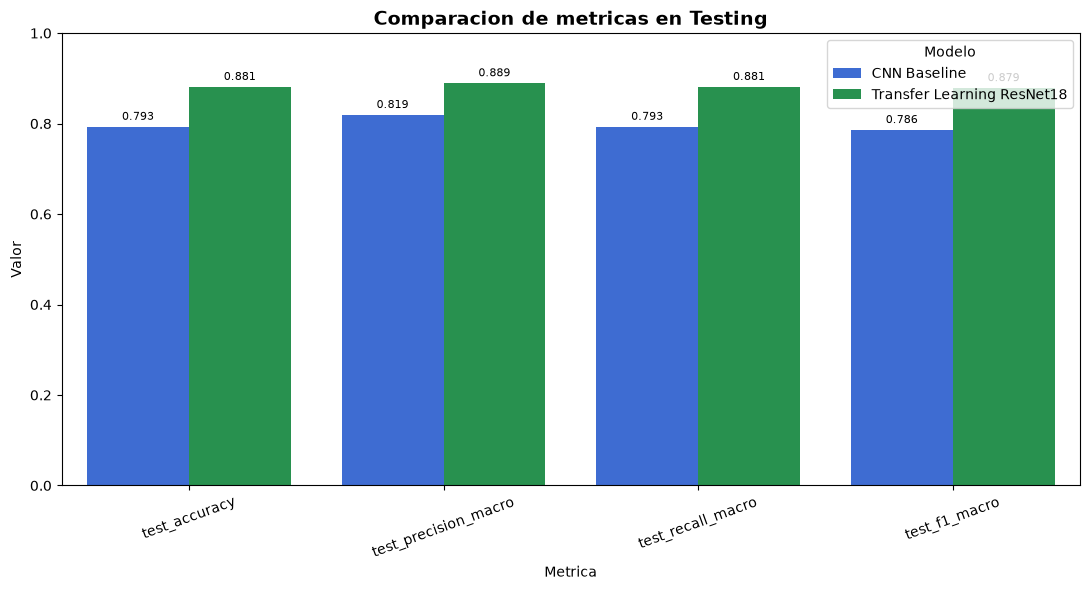

Figura de comparacion guardada en: c:\Users\admin\Desktop\Maestria en BI y Analisis de Datos\M3\06 - Redes Neuronales y Deep Learning\Proyecto Final\outputs\figures\baseline_vs_transfer_metrics_comparison.png

Mejoras absolutas de Transfer Learning frente al baseline:
test_accuracy: +0.0881
test_precision_macro: +0.0702
test_recall_macro: +0.0881
test_f1_macro: +0.0927


In [23]:
# Paso 24 - Comparacion contra CNN baseline

with open(BASELINE_METRICS_PATH, "r", encoding="utf-8") as file:
    baseline_metrics = json.load(file)

with open(TRANSFER_METRICS_PATH, "r", encoding="utf-8") as file:
    transfer_metrics = json.load(file)

comparison_rows = [
    {
        "model": "CNN Baseline",
        "test_loss": baseline_metrics["test_loss"],
        "test_accuracy": baseline_metrics["test_accuracy"],
        "test_precision_macro": baseline_metrics["test_precision_macro"],
        "test_recall_macro": baseline_metrics["test_recall_macro"],
        "test_f1_macro": baseline_metrics["test_f1_macro"],
    },
    {
        "model": "Transfer Learning ResNet18",
        "test_loss": transfer_metrics["test_loss"],
        "test_accuracy": transfer_metrics["test_accuracy"],
        "test_precision_macro": transfer_metrics["test_precision_macro"],
        "test_recall_macro": transfer_metrics["test_recall_macro"],
        "test_f1_macro": transfer_metrics["test_f1_macro"],
    },
]

comparison_df = pd.DataFrame(comparison_rows)

metric_columns = [
    "test_accuracy",
    "test_precision_macro",
    "test_recall_macro",
    "test_f1_macro",
]

for metric in metric_columns:
    baseline_value = comparison_df.loc[comparison_df["model"] == "CNN Baseline", metric].values[0]
    transfer_value = comparison_df.loc[comparison_df["model"] == "Transfer Learning ResNet18", metric].values[0]
    comparison_df.loc[comparison_df["model"] == "Transfer Learning ResNet18", f"{metric}_improvement"] = transfer_value - baseline_value
    comparison_df.loc[comparison_df["model"] == "CNN Baseline", f"{metric}_improvement"] = 0.0

display(comparison_df)

comparison_long_df = comparison_df.melt(
    id_vars="model",
    value_vars=metric_columns,
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=comparison_long_df,
    x="metric",
    y="value",
    hue="model",
    palette=["#2563eb", "#16a34a"]
)

plt.title("Comparacion de metricas en Testing", fontsize=14, fontweight="bold")
plt.xlabel("Metrica")
plt.ylabel("Valor")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(title="Modelo")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=8)

plt.tight_layout()

comparison_figure_path = FIGURES_DIR / "baseline_vs_transfer_metrics_comparison.png"
plt.savefig(comparison_figure_path, dpi=150, bbox_inches="tight")

plt.show()

print(f"Figura de comparacion guardada en: {comparison_figure_path}")

print("\nMejoras absolutas de Transfer Learning frente al baseline:")
for metric in metric_columns:
    improvement = comparison_df.loc[
        comparison_df["model"] == "Transfer Learning ResNet18",
        f"{metric}_improvement"
    ].values[0]
    print(f"{metric}: +{improvement:.4f}")

### Interpretación de la comparación contra la CNN baseline

La comparación confirma que el modelo de transfer learning con ResNet18 superó a la CNN baseline en todas las métricas principales sobre el conjunto `Testing`.

La CNN baseline obtuvo una accuracy de `0.7931`, mientras que ResNet18 alcanzó `0.8813`. Esto representa una mejora absoluta de `0.0881`, equivalente a 8.81 puntos porcentuales.

También se observa una mejora en precision macro, recall macro y F1 macro:

- Precision macro: mejora de `0.0702`.
- Recall macro: mejora de `0.0881`.
- F1 macro: mejora de `0.0927`.

Además, la pérdida en Testing disminuyó de `0.6702` en el baseline a `0.4356` en ResNet18, lo que indica un mejor ajuste general del modelo transfer learning sobre datos no vistos.

En conjunto, estos resultados muestran que el uso de transfer learning y fine-tuning parcial aportó una mejora clara frente a entrenar una CNN desde cero.

## 25. Conclusiones del notebook

En este notebook se entrenó y evaluó un modelo de transfer learning basado en ResNet18 para clasificar imágenes de resonancia magnética cerebral en cuatro clases:

- `glioma`
- `meningioma`
- `notumor`
- `pituitary`

El flujo de trabajo siguió la misma lógica general del notebook baseline:

1. Validación de estructura del dataset.
2. Análisis exploratorio visual y técnico.
3. Preprocesamiento uniforme.
4. Data augmentation moderado.
5. División train/validation desde `Training/`.
6. Evaluación final exclusiva sobre `Testing/`.
7. Guardado de modelo, métricas y visualizaciones.
8. Comparación contra la CNN baseline.

El modelo ResNet18 fue entrenado en dos fases. Primero se congeló la red base y se entrenó únicamente la cabeza clasificadora. Luego se realizó fine-tuning parcial descongelando `layer4` y la cabeza final.

Los resultados finales en `Testing` fueron:

- Accuracy: `0.8813`
- Precision macro: `0.8895`
- Recall macro: `0.8813`
- F1 macro: `0.8787`

Comparado con la CNN baseline, el modelo transfer learning mejoró el F1 macro de `0.7860` a `0.8787`, y la accuracy de `0.7931` a `0.8813`.

La matriz de confusión mostró que las clases `notumor` y `pituitary` fueron clasificadas con mayor facilidad. La principal dificultad se mantuvo en la separación entre `glioma` y `meningioma`, donde todavía existen confusiones relevantes.

En conclusión, transfer learning con ResNet18 y fine-tuning parcial fue el mejor enfoque entre los dos modelos evaluados hasta ahora. Además, ResNet18 sigue siendo una arquitectura relativamente liviana, por lo que es una buena candidata para integrarse posteriormente en una aplicación Streamlit de inferencia.